### NovaPay FraudGuard: Real-Time Fraud Detection

The purpose of this project is to develop a machine learning-based fraud detection system for NovaPay, replacing its existing static, rules-based approach


### Problem Statement

The purpose of this project is to develop a machine learning-based fraud detection system for NovaPay, replacing its existing static, rules-based approach. The solution will aim to enhance the accuracy of detecting fraudulent transactions while minimizing the rate of false positives (legitimate transactions wrongly flagged as fraudulent). 

This will ensure that customers have a smoother experience and trust in the service while also reducing the operational and financial impact of fraud. The machine learning model will be capable of evolving as fraud tactics change, providing long-term adaptability and scalability.

### Specific Objectives
- *Clean and prepare the dataset for analysis and modeling*
- *Explore booking data to understand patterns, trends, and cancellation behavior*
- *Perform comprehensive analysis to identify key factors influencing fraud*
- *Engineer meaningful features that improve the predictive power of the dataset*
- *Develop a machine learning model to predict fraud detection accurately*
- *Evaluate model performance using appropriate metrics for classification*
- *Fine-tune the model to improve accuracy, reliability, and generalization*
- *Generate actionable insights that support better customer retention and reduce fraud detection*

#### Data Dictionary

The NovaPay dataset contains information about cross-border money-transfer transactions.  
Each row represents one transaction made by a NovaPay customer.

The dataset combines:

- Transaction information
- Customer information
- Currency and payment information
- Device and internet-location information
- Customer behavioural history
- Fraud-risk indicators
- The final fraud outcome

The table below explains the meaning of each variable used in the analysis.

| Column | Meaning |
|---|---|
| `transaction_id` | A unique identification number assigned to each transaction. It is used to trace or reference a particular transaction but is not normally used as a direct machine-learning feature. |
| `customer_id` | A unique identification number assigned to each NovaPay customer. One customer can have several transactions, so the same customer ID may appear in multiple rows. |
| `timestamp_clean` | The cleaned date and exact time when the transaction occurred. Invalid or unusable timestamps were handled during data cleaning, and valid timestamps were converted to a standard datetime format. |
| `home_country_clean` | The customer's registered home country after correcting spaces, inconsistent labels and missing values. The main values are `US`, `UK` and `CA`. |
| `source_currency` | The currency in which the customer sends the money. Examples include `USD`, `GBP` and `CAD`. |
| `dest_currency` | The currency that the recipient receives. Examples include `NGN`, `EUR`, `INR`, `PHP`, `MXN`, `CAD`, `GBP` and `USD`. |
| `channel` | The platform through which the transaction was initiated. The cleaned categories are `mobile`, `web`, `ATM` and `unknown`. |
| `amount_src_clean` | The cleaned amount of money sent by the customer in the source currency. For example, if the source currency is GBP and the value is 200, the customer sent £200. |
| `amount_usd_clean` | The transaction amount converted into United States dollars. This creates a common currency that allows transactions in GBP, CAD and USD to be compared fairly. |
| `fee_clean` | The cleaned transaction-processing fee charged by NovaPay. Missing and invalid fees were reconstructed using the observed relationship between the transaction amount and the fee. |
| `exchange_rate_src_to_dest` | The exchange rate used to convert one unit of the source currency into the destination currency. For example, it may show how many Canadian dollars are received for one US dollar. |
| `device_id` | A unique identification number assigned to the device used for the transaction. The same device may appear in several transactions. |
| `new_device` | Indicates whether the device is new to the customer. `True` means the customer has not previously used the device, while `False` means it is an existing or recognised device. |
| `ip_country_clean` | The cleaned country associated with the IP address used during the transaction. It represents the country from which the customer appeared to connect. |
| `location_mismatch` | Indicates whether the IP country differs from the customer's registered home country. `True` means the countries differ, while `False` means they match. |
| `ip_risk_score` | A numerical score representing the level of risk associated with the IP address. Higher values generally indicate a riskier or more suspicious internet connection. |
| `kyc_tier_clean` | The customer's cleaned Know Your Customer verification level. The categories are `low`, `standard`, `enhanced` and `unknown`. Enhanced KYC generally represents more detailed identity verification. |
| `account_age_days` | The number of days between the creation of the customer's account and the transaction. Smaller values represent newer accounts. |
| `device_trust_score_clean` | A cleaned numerical score representing how trustworthy NovaPay considers the device. The score ranges from 0 to 1, where lower values indicate lower trust and higher values indicate greater trust. |
| `chargeback_history_count` | The number of previous chargebacks associated with the customer. A chargeback occurs when a payment is disputed or reversed. |
| `risk_score_internal` | NovaPay's existing internal risk score for the customer or transaction. Higher values generally represent higher estimated risk. |
| `txn_velocity_1h` | The number of recent transactions associated with the customer within a one-hour period. A high value may indicate unusually rapid transaction activity. |
| `txn_velocity_24h` | The number of recent transactions associated with the customer within a 24-hour period. It measures the customer's daily transaction frequency. |
| `corridor_risk` | A risk score associated with the source-to-destination currency route. For example, `USD → NGN` and `GBP → EUR` represent different transaction corridors that may have different historical risk levels. |
| `is_fraud` | The target variable showing the final transaction outcome. `0` represents a legitimate transaction, while `1` represents a fraudulent transaction. |

---

#### Engineered Time Variables

The following variables were created from `timestamp_clean` to help analyse when transactions occurred.

| Column | Meaning |
|---|---|
| `transaction_year` | The year in which the transaction occurred. |
| `transaction_month_name` | The full name of the month in which the transaction occurred, such as `January`, `June` or `October`. |
| `transaction_day_of_week` | The day of the week on which the transaction occurred, such as `Monday`, `Friday` or `Sunday`. |
| `transaction_hour` | The hour when the transaction occurred, recorded using the 24-hour clock. Values range from 0 to 23. |
| `is_weekend` | Indicates whether the transaction occurred on Saturday or Sunday. |
| `is_night_transaction` | Indicates whether the transaction occurred during the defined night-time period, such as between midnight and 5:59 a.m. |

---

#### 🎯 Target Variable

The machine-learning model will predict:

##### `is_fraud`

- `0` = Legitimate transaction
- `1` = Fraudulent transaction

This makes the project a **binary classification problem** because the model must choose between two possible outcomes.

---

#### How to Interpret One Transaction

A single row can be read as a transaction story:

> A customer registered in the United States used the mobile channel to send USD to a recipient receiving Nigerian naira. The customer used a new device, connected through a different country, had a relatively high IP-risk score and completed several transactions within one hour. The `is_fraud` column shows whether the transaction was eventually confirmed as legitimate or fraudulent.

The machine-learning model will examine combinations of these transaction, customer, device and behavioural characteristics to estimate the probability that a new transaction is fraudulent.

#### Import Relevant Libraries

In [361]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set_style(None)

from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

#### Load Dataset

In [362]:
data =pd.read_csv(r'C:\Users\hp\Desktop\Amdari Internship\Projects\Anomaly-Detection-for-fraud-unusual-activity\data\nova_pay_combined.csv')

In [363]:
# Inspection of Data
data.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [364]:
# Data dimension check and structural summary

print(f'Dataset shape: {data.shape[0]} rows x {data.shape[1]} columns')
data.info()

Dataset shape: 11400 rows x 26 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_addr

In [365]:
# Descriptive Statistics (Statistical Summary)

data.describe().round(2)

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.00,11105.00,11400.00,11400.00,11400.00,11105.00,11400.00,11400.00,11400.00,11400.00,11400.00,11400.00
mean,452.02,100.31,167.54,0.40,393.79,0.65,0.05,0.27,0.46,0.72,0.05,0.09
std,1403.97,958.13,382.02,0.27,342.35,0.27,0.26,0.14,1.52,1.96,0.08,0.28
min,7.23,-1.00,0.59,0.00,1.00,-0.10,0.00,0.00,-1.00,0.00,0.00,0.00
25%,92.46,2.38,1.00,0.21,147.00,0.52,0.00,0.17,0.00,0.00,0.00,0.00
50%,163.48,3.50,7.14,0.32,298.00,0.66,0.00,0.22,0.00,0.00,0.00,0.00
75%,302.19,5.55,73.53,0.49,661.00,0.89,0.00,0.39,0.00,0.00,0.05,0.00
max,12498.57,9999.99,1388.89,1.20,1095.00,1.00,2.00,0.90,8.00,11.00,0.25,1.00


In [366]:
data.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

### Data Cleaning and Preprocessing

#### a. Investigate and Duplicates

In [367]:
data_2 = data.drop_duplicates().copy()

print(data_2.shape)
print(data_2["amount_usd"].isna().sum())

(11200, 26)
300


#### b.Investigate and Handle Missing Data

In [368]:
missing = data_2.isnull().sum()
print('Missing values:')
print (missing)
print()

if missing.sum()==0:
    print('Good news! No missing values')
else:
    print('We have missing values that requires handling')

Missing values:
transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

We have missing values that requires handling


There is a serous issue of missing values. Let address this missing values.

#### Handle Missing Data

In [369]:
missing = data.isnull().sum()
print('Missing values:')
print (missing)
print()

if missing.sum()==0:
    print('Good news! No missing values')
else:
    print('We have missing values that requires handling')

Missing values:
transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

We have missing values that requires handling


In [370]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  object 
 1   customer_id                11200 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11200 non-null  object 
 4   source_currency            11200 non-null  object 
 5   dest_currency              11200 non-null  object 
 6   channel                    11200 non-null  object 
 7   amount_src                 11200 non-null  object 
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  object 
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  object 


Although amount_src looks numeric, pandas reads it as text because some values contain commas. Let convert it to numeric, before doing anything

In [371]:
data_2["amount_src"] = pd.to_numeric(data_2["amount_src"]
                                      .astype(str)
                                      .str.replace(",", "", regex=False)
                                      .str.strip(),
                                      errors="coerce"
)

Checking which currencies has USD missing values

In [372]:
missing_amount_usd = data_2[
    data["amount_usd"].isna()
]

missing_amount_usd["source_currency"].value_counts()

source_currency
USD    211
GBP     66
CAD     23
Name: count, dtype: int64

Let find the conversion rates already used in the dataset

In [373]:
valid_rate_rows = (
    data_2["amount_usd"].notna()
    & data_2["amount_src"].gt(0)
    & data_2["amount_usd"].gt(0)
)

data_2.loc[
    valid_rate_rows,
    "implied_usd_rate"
] = (
    data_2.loc[valid_rate_rows, "amount_usd"]
    / data_2.loc[valid_rate_rows, "amount_src"]
)

In [374]:
usd_rate_table = (
    data_2.loc[valid_rate_rows]
        .groupby("source_currency")["implied_usd_rate"]
        .median()
)

print(usd_rate_table)

source_currency
CAD    0.74
GBP    1.25
USD    1.00
Name: implied_usd_rate, dtype: float64


In [375]:
# Mapping  the source currencies to their USD rates
data_2["source_to_usd_rate"] = (
    data_2["source_currency"].map(usd_rate_table)
)

In [376]:
#Create a clean USD column
data_2["amount_usd_clean"] = data_2["amount_usd"]

In [377]:
# Identify rows that are safe to fill becuase of the values are negative, probably indicating a reversal, refund or a mistake
safe_to_fill = (
    data_2["amount_usd_clean"].isna()
    & data_2["amount_src"].gt(0)
    & data_2["source_to_usd_rate"].notna()
)

In [378]:
#Let fill in the safe missing values
data_2.loc[
    safe_to_fill,
    "amount_usd_clean"
] = (
    data_2.loc[safe_to_fill, "amount_src"]
    *data_2.loc[safe_to_fill, "source_to_usd_rate"]
).round(2)

In [379]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  object 
 1   customer_id                11200 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11200 non-null  object 
 4   source_currency            11200 non-null  object 
 5   dest_currency              11200 non-null  object 
 6   channel                    11200 non-null  object 
 7   amount_src                 11200 non-null  float64
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  object 
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  object 


In [380]:
# Investigate the remaining rows that are showing negative
remaining_missing = data_2[
    data_2["amount_usd_clean"].isna()
][[
    "transaction_id",
    "source_currency",
    "dest_currency",
    "amount_src",
    "amount_usd",
    "exchange_rate_src_to_dest",
    "is_fraud"
]]

remaining_missing

,transaction_id,source_currency,dest_currency,amount_src,amount_usd,exchange_rate_src_to_dest,is_fraud
1311,e9c7f2cb-f2de-4603-b38f-f2f66ec1eee1,USD,CNY,-165.36,NaN,7.142857,0
4589,ef0f7b00-c2cf-4a26-8e47-8662cb672404,USD,USD,-33.67,NaN,1.000000,0
6045,c443124e-dcc1-4e4c-8369-c3f06e9c2434,USD,CAD,-373.89,NaN,1.351351,0


These amount_src columns are showing negative values. Let's investigate more.

In [381]:
negative_transactions = data_2[
    data_2["amount_src"] < 0
].copy()

print("Number of negative transactions:")
print(len(negative_transactions))

Number of negative transactions:
100


In [382]:
print(
    negative_transactions["amount_usd"]
    .isna()
    .sum()
)

3


Since most available USD amounts are positive even though amount_src is negative.

This suggests that the negative sign in amount_src is an error rather than a properly recorded reversal.

Other suspicious pattern in the dataset

- A fee of 9999.99 is unrealistic for these relatively small transactions.
- If ip_risk_score should be between 0 and 1, then 1.2 is invalid.
- If device_trust_score should be between 0 and 1, then -0.1 is invalid.
- A customer cannot make -1 transactions in an hour.

In [383]:
#Verify the pattern

print(
    "All fees are 9999.99:",
    negative_transactions["fee"].eq(9999.99).all()
)

print(
    "All IP risk scores exceed 1:",
    negative_transactions["ip_risk_score"].gt(1).all()
)

print(
    "All device trust scores are negative:",
    negative_transactions["device_trust_score"].lt(0).all()
)

print(
    "All hourly velocities are negative:",
    negative_transactions["txn_velocity_1h"].lt(0).all()
)

All fees are 9999.99: True
All IP risk scores exceed 1: True
All device trust scores are negative: True
All hourly velocities are negative: True


This is very important, because
a genuine reversal might reasonably have a negative amount, but it would not normally cause all these unrelated columns to become impossible at the same time.

Therefore, these rows appear to be deliberately corrupted data-quality records, not properly recorded reversals.

In [384]:
# Let's identifies the complete pattern

data_2["corrupt_record_flag"] = (
    (data_2["amount_src"] < 0)
    & (data_2["fee"] == 9999.99)
    & (data_2["ip_risk_score"] > 1)
    & (data_2["device_trust_score"] < 0)
    & (data_2["txn_velocity_1h"] < 0)
)

In [385]:
# First, separate them into another dataframe

corrupt_rows = data_2[
    data_2["corrupt_record_flag"]
].copy()


# clean modelling dataset
model_df = data_2[
    ~data_2["corrupt_record_flag"]
].copy()

In [386]:
# Checking shape
print("Original cleaned data:", data_2.shape)
print("Quarantined rows:", corrupt_rows.shape)
print("Modelling data:", model_df.shape)

Original cleaned data: (11200, 30)
Quarantined rows: (100, 30)
Modelling data: (11100, 30)


In [387]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11100 entries, 0 to 11399
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11100 non-null  object 
 1   customer_id                11100 non-null  object 
 2   timestamp                  11071 non-null  object 
 3   home_country               11100 non-null  object 
 4   source_currency            11100 non-null  object 
 5   dest_currency              11100 non-null  object 
 6   channel                    11100 non-null  object 
 7   amount_src                 11100 non-null  float64
 8   amount_usd                 10803 non-null  float64
 9   fee                        10810 non-null  float64
 10  exchange_rate_src_to_dest  11100 non-null  float64
 11  device_id                  11100 non-null  object 
 12  new_device                 11100 non-null  bool   
 13  ip_address                 10803 non-null  object 


In [388]:
# Checking from missing values in the dataset after separating the negative values
model_df.isna().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   297
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   297
ip_country                   293
location_mismatch              0
ip_risk_score                  0
kyc_tier                     292
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
implied_usd_rate             297
source_to_usd_rate             0
amount_usd_clean               0
corrupt_record_flag            0
dtype: int

In [389]:

# Remove exact duplicates
data = data.drop_duplicates().copy()

# Preserve original amount
data["amount_src_original"] = data["amount_src"]

# Convert source amount to numeric
data["amount_src_clean"] = pd.to_numeric(
    data["amount_src"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip(),
    errors="coerce"
)

# Flag negative source amounts
data["amount_src_negative_flag"] = (
    data["amount_src_clean"] < 0
)

# Correct the negative sign
data["amount_src_corrected"] = (
    data["amount_src_clean"].abs()
)

# Record which rows were corrected
data["amount_src_was_corrected"] = (
    data["amount_src_negative_flag"]
)

# USD conversion rates found in the dataset
usd_rates = {
    "USD": 1.00,
    "GBP": 1.25,
    "CAD": 0.74
}

# Attach USD rate
data["source_to_usd_rate"] = (
    data["source_currency"].map(usd_rates)
)

# Create clean USD column
data["amount_usd_clean"] = (
    data["amount_usd"]
)

# Identify missing USD amounts that can be reconstructed
missing_usd_mask = (
    data["amount_usd_clean"].isna()
    & data["amount_src_corrected"].notna()
    & data["source_to_usd_rate"].notna()
)

# Fill missing USD amounts
data.loc[
    missing_usd_mask,
    "amount_usd_clean"
] = (
    data.loc[
        missing_usd_mask,
        "amount_src_corrected"
    ]
    * data.loc[
        missing_usd_mask,
        "source_to_usd_rate"
    ]
).round(2)

# Record which USD amounts were filled
data["amount_usd_was_imputed"] = (
    missing_usd_mask
)

# Confirm results
print(
    "Source amounts corrected:",
    data["amount_src_was_corrected"].sum()
)

print(
    "Negative amounts remaining:",
    (data["amount_src_corrected"] < 0).sum()
)

print(
    "USD amounts filled:",
    data["amount_usd_was_imputed"].sum()
)

print(
    "USD amounts still missing:",
    data["amount_usd_clean"].isna().sum()
)

Source amounts corrected: 100
Negative amounts remaining: 0
USD amounts filled: 300
USD amounts still missing: 0


In [390]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  object 
 1   customer_id                11200 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11200 non-null  object 
 4   source_currency            11200 non-null  object 
 5   dest_currency              11200 non-null  object 
 6   channel                    11200 non-null  object 
 7   amount_src                 11200 non-null  object 
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  object 
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  object 


In [391]:
# Checking from missing values in the dataset after separating the negative values
data.isna().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
amount_src_original            0
amount_src_clean               0
amount_src_negative_flag       0
amount_src_corrected           0
amount_src

In [392]:
data = data.drop_duplicates() #Remove duplicates

Addressing the missing values in this column after resolving the issue of negative

fee
ip_country
kyc_tier
timestamp
device_trust_score
ip_address(since I won't needing the ip_address, I won't bother about the missing values)

### Handling Missing-Values

In [393]:
#Fee
data["fee"].describe()

count    10910.000000
mean        99.212001
std        952.526927
min         -1.000000
25%          2.380000
50%          3.500000
75%          5.560000
max       9999.990000
Name: fee, dtype: float64

We can see more issues with the fee columns
values -1 and 9999.99 appear to be error. They should be treated as missing before imputation.

In [394]:
data["amount_src_corrected"] = pd.to_numeric(
    data["amount_src"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip(),
    errors="coerce"
).abs()



# Keep the original fee column
data["fee_original"] = data["fee"]


# Let Flag originally missing fees
data["fee_was_missing"] = (
    data["fee"].isna()
)

# invalid fees
data["fee_was_invalid"] = (
    (data["fee"] < 0)
    | (data["fee"] == 9999.99)
)


# Create the clean fee column
data["fee_clean"] = data["fee"]

data.loc[
    data["fee_was_invalid"],
    "fee_clean"
] = pd.NA


# Select valid rows for training
fee_training_mask = (
    data["fee_clean"].notna()
    & data["amount_src_corrected"].notna()
    & data["amount_src_corrected"].gt(0)
)


# Train the fee-imputation model
X_fee = data.loc[
    fee_training_mask,
    ["amount_src_corrected"]
]

y_fee = data.loc[
    fee_training_mask,
    "fee_clean"
]

#Import the needed lib, fitting it
from sklearn.linear_model import LinearRegression
fee_model = LinearRegression()

fee_model.fit(X_fee, y_fee)



#Display the learned relationship

print("Intercept:", fee_model.intercept_)
print("Coefficient:", fee_model.coef_[0])


#Identify missing or invalid fees

fee_imputation_mask = (
    data["fee_clean"].isna()
    & data["amount_src_corrected"].notna()
)


#Predict the missing fees

predicted_fees = fee_model.predict(
    data.loc[
        fee_imputation_mask,
        ["amount_src_corrected"]
    ]
)

predicted_fees = (
    pd.Series(predicted_fees)
      .clip(lower=0)
      .round(2)
      .to_numpy()
)

# 12. Insert the predicted fees

data.loc[
    fee_imputation_mask,
    "fee_clean"
] = predicted_fees



#Record which fees were imputed

data["fee_was_imputed"] = (
    fee_imputation_mask
)

# Check the final results
print(
    "Originally missing:",
    data["fee_was_missing"].sum()
)

print(
    "Originally invalid:",
    data["fee_was_invalid"].sum()
)

print(
    "Fees imputed:",
    data["fee_was_imputed"].sum()
)

print(
    "Fees still missing:",
    data["fee_clean"].isna().sum()
)

Intercept: 1.000517043834515
Coefficient: 0.015004582584595562
Originally missing: 290
Originally invalid: 200
Fees imputed: 490
Fees still missing: 0


In [395]:
#IP country
print(data["ip_country"].isna().sum())

296


In [396]:

# Keep the original IP country

data["ip_country_original"] = data["ip_country"]


# Clean home_country
data["home_country_clean"] = (
    data["home_country"]
    .astype("string")
    .str.strip()
    .str.upper()
)



#Clean ip_country

data["ip_country_clean"] = (
    data["ip_country"]
    .astype("string")
    .str.strip()
    .str.upper()
)


#Convert placeholder strings into missing values

missing_country_tokens = [
    "",
    "NAN",
    "UNKNOWN",
    "NONE",
    "NULL"
]

data.loc[
    data["home_country_clean"].isin(missing_country_tokens),
    "home_country_clean"
] = pd.NA

data.loc[
    data["ip_country_clean"].isin(missing_country_tokens),
    "ip_country_clean"
] = pd.NA


#Flag unusable original IP-country values

data["ip_country_was_missing"] = (
    data["ip_country_clean"].isna()
)

# Create treatment column

data["ip_country_treatment"] = "ORIGINAL"


#Reconstruct IP country from home country only when location_mismatch is False

reconstruct_from_home = (
    data["ip_country_clean"].isna()
    & data["location_mismatch"].eq(False)
    & data["home_country_clean"].notna()
)

data.loc[
    reconstruct_from_home,
    "ip_country_clean"
] = data.loc[
    reconstruct_from_home,
    "home_country_clean"
]

data.loc[
    reconstruct_from_home,
    "ip_country_treatment"
] = "RECONSTRUCTED_FROM_HOME"


#Exact IP country is unknown, but it is known to differ from the home country

unknown_mismatch = (
    data["ip_country_clean"].isna()
    & data["location_mismatch"].eq(True)
)

data.loc[
    unknown_mismatch,
    "ip_country_clean"
] = "UNKNOWN_MISMATCH"

data.loc[
    unknown_mismatch,
    "ip_country_treatment"
] = "UNKNOWN_MISMATCH"


#Handle completely unresolved countries

still_unknown = data["ip_country_clean"].isna()

data.loc[
    still_unknown,
    "ip_country_clean"
] = "UNKNOWN"

data.loc[
    still_unknown,
    "ip_country_treatment"
] = "UNKNOWN"



#Final checks

print(
    "Originally unusable:",
    data["ip_country_was_missing"].sum()
)

print(
    "Reconstructed from home:",
    data["ip_country_treatment"]
    .eq("RECONSTRUCTED_FROM_HOME")
    .sum()
)

print(
    "Unknown mismatch:",
    data["ip_country_treatment"]
    .eq("UNKNOWN_MISMATCH")
    .sum()
)

print(
    "Completely unknown:",
    data["ip_country_treatment"]
    .eq("UNKNOWN")
    .sum()
)

print(
    "Missing IP countries remaining:",
    data["ip_country_clean"].isna().sum()
)

Originally unusable: 331
Reconstructed from home: 294
Unknown mismatch: 34
Completely unknown: 3
Missing IP countries remaining: 0


In [397]:
#Fee

#Keep the original column

data["kyc_tier_original"] = data["kyc_tier"]



#Standardize spaces and capitalization

data["kyc_tier_clean"] = (
    data["kyc_tier"]
    .astype("string")
    .str.strip()
    .str.lower()
)


#Correct spelling mistake

kyc_corrections = {
    "standrd": "standard",
    "enhancd": "enhanced"
}

data["kyc_tier_clean"] = (
    data["kyc_tier_clean"]
    .replace(kyc_corrections)
)

#Convert placeholder strings to missing values

missing_kyc_tokens = [
    "",
    "nan",
    "unknown",
    "none",
    "null"
]

data.loc[
    data["kyc_tier_clean"].isin(missing_kyc_tokens),
    "kyc_tier_clean"
] = pd.NA


#Flag originally unusable KYC values

data["kyc_tier_was_missing"] = (
    data["kyc_tier_clean"].isna()
)


#Check customer-level KYC consistency

customer_kyc_counts = (
    data
    .dropna(subset=["kyc_tier_clean"])
    .groupby("customer_id")["kyc_tier_clean"]
    .nunique()
)

conflicting_customers = customer_kyc_counts[
    customer_kyc_counts > 1
]

print(
    "Customers with conflicting KYC tiers:",
    len(conflicting_customers)
)

#Create customer-to-KYC mapping

customer_kyc_map = (
    data
    .dropna(subset=["kyc_tier_clean"])
    .groupby("customer_id")["kyc_tier_clean"]
    .first()
)


#Identify KYC values recoverable from customer

kyc_from_customer = (
    data["kyc_tier_clean"].isna()
    & data["customer_id"]
        .map(customer_kyc_map)
        .notna()
)

# Fill using the same customer's KYC tier


data.loc[
    kyc_from_customer,
    "kyc_tier_clean"
] = (
    data.loc[
        kyc_from_customer,
        "customer_id"
    ].map(customer_kyc_map)
)



#Identify remaining unresolved values

remaining_kyc_missing = (
    data["kyc_tier_clean"].isna()
)


#Use a transparent unknown category


data.loc[
    remaining_kyc_missing,
    "kyc_tier_clean"
] = "unknown"


#Record the treatment method

data["kyc_tier_treatment"] = (
    "original_or_standardized"
)

data.loc[
    kyc_from_customer,
    "kyc_tier_treatment"
] = "reconstructed_from_customer"

data.loc[
    remaining_kyc_missing,
    "kyc_tier_treatment"
] = "unknown"



#Create imputation flag
data["kyc_tier_was_imputed"] = (
    kyc_from_customer
    | remaining_kyc_missing
)


#Final validation


print(
    "Originally unusable:",
    data["kyc_tier_was_missing"].sum()
)

print(
    "Reconstructed from customer:",
    data["kyc_tier_treatment"]
    .eq("reconstructed_from_customer")
    .sum()
)

print(
    "Assigned unknown:",
    data["kyc_tier_treatment"]
    .eq("unknown")
    .sum()
)

print(
    "Missing KYC tiers remaining:",
    data["kyc_tier_clean"].isna().sum()
)

print("\nFinal KYC distribution:")
print(
    data["kyc_tier_clean"]
    .value_counts(dropna=False)
)

Customers with conflicting KYC tiers: 0
Originally unusable: 329
Reconstructed from customer: 327
Assigned unknown: 2
Missing KYC tiers remaining: 0

Final KYC distribution:
kyc_tier_clean
standard    8240
enhanced    1900
low         1058
unknown        2
Name: count, dtype: Int64


In [398]:
# Keep original timestamp


data["timestamp_original"] = data["timestamp"]



#Convert timestamp to datetime

data["timestamp_clean"] = pd.to_datetime(
    data["timestamp"],
    errors="coerce",
    utc=True,
    format="mixed"
)


#Flag originally missing timestamps

data["timestamp_was_missing"] = (
    data["timestamp_original"].isna()
)


#Flag invalid timestamp strings

data["timestamp_was_invalid"] = (
    data["timestamp_original"].notna()
    & data["timestamp_clean"].isna()
)


# Create overall unusable-timestamp flag

data["timestamp_unusable_flag"] = (
    data["timestamp_clean"].isna()
)


#Display diagnostic counts

print(
    "Originally missing:",
    data["timestamp_was_missing"].sum()
)

print(
    "Invalid timestamp strings:",
    data["timestamp_was_invalid"].sum()
)

print(
    "Total unusable timestamps:",
    data["timestamp_unusable_flag"].sum()
)


# Quarantine affected rows

timestamp_quarantine = data.loc[
    data["timestamp_unusable_flag"]
].copy()

timestamp_quarantine.to_csv(
    "quarantined_timestamp_records.csv",
    index=False
)


#Remove records without valid timestamps

data = data.loc[
    ~data["timestamp_unusable_flag"]
].copy()


# Create time features

data["transaction_year"] = (
    data["timestamp_clean"].dt.year
)

data["transaction_month"] = (
    data["timestamp_clean"].dt.month
)

data["transaction_hour"] = (
    data["timestamp_clean"].dt.hour
)

data["transaction_day_of_week"] = (
    data["timestamp_clean"].dt.day_name()
)

data["is_weekend"] = (
    data["timestamp_clean"].dt.dayofweek >= 5
)

data["is_night_transaction"] = (
    data["transaction_hour"].between(0, 5)
)


# Final checks

print(
    "Rows quarantined:",
    len(timestamp_quarantine)
)

print(
    "Rows remaining:",
    len(data)
)

print(
    "Missing timestamps remaining:",
    data["timestamp_clean"].isna().sum()
)

Originally missing: 29
Invalid timestamp strings: 31
Total unusable timestamps: 60
Rows quarantined: 60
Rows remaining: 11140
Missing timestamps remaining: 0


In [399]:
#Keep the original score

data["device_trust_score_original"] = (
    data["device_trust_score"]
)

#Convert to numeric

data["device_trust_score_clean"] = pd.to_numeric(
    data["device_trust_score"],
    errors="coerce"
)


#Flag actually missing values

data["device_trust_was_missing"] = (
    data["device_trust_score_original"].isna()
)


# Flag scores outside the valid 0–1 range

data["device_trust_was_invalid"] = (
    data["device_trust_score_clean"].notna()
    & ~data["device_trust_score_clean"].between(0, 1)
)


#Convert invalid scores to missing

data.loc[
    data["device_trust_was_invalid"],
    "device_trust_score_clean"
] = pd.NA


#Flag all values requiring treatment

data["device_trust_was_unusable"] = (
    data["device_trust_score_clean"].isna()
)


#Record the treatment method

data["device_trust_treatment"] = "original_valid"


# Identify originally valid score records

valid_device_score_mask = (
    data["device_trust_score_clean"].notna()
)


#Calculate each device's median score

device_score_map = (
    data.loc[valid_device_score_mask]
    .groupby("device_id")["device_trust_score_clean"]
    .median()
)

#Fill from the same device

fill_from_device = (
    data["device_trust_score_clean"].isna()
    & data["device_id"].map(device_score_map).notna()
)

data.loc[
    fill_from_device,
    "device_trust_score_clean"
] = (
    data.loc[
        fill_from_device,
        "device_id"
    ].map(device_score_map)
)

data.loc[
    fill_from_device,
    "device_trust_treatment"
] = "same_device_median"


#Calculate each customer's median score

customer_score_map = (
    data.loc[valid_device_score_mask]
    .groupby("customer_id")["device_trust_score_clean"]
    .median()
)



# 12. Fill from the same customer
fill_from_customer = (
    data["device_trust_score_clean"].isna()
    & data["customer_id"].map(customer_score_map).notna()
)

data.loc[
    fill_from_customer,
    "device_trust_score_clean"
] = (
    data.loc[
        fill_from_customer,
        "customer_id"
    ].map(customer_score_map)
)

data.loc[
    fill_from_customer,
    "device_trust_treatment"
] = "same_customer_median"


#Calculate median by new_device status

new_device_score_map = (
    data.loc[valid_device_score_mask]
    .groupby("new_device")["device_trust_score_clean"]
    .median()
)


#Fill the final unresolved values

fill_from_device_status = (
    data["device_trust_score_clean"].isna()
    & data["new_device"]
        .map(new_device_score_map)
        .notna()
)

data.loc[
    fill_from_device_status,
    "device_trust_score_clean"
] = (
    data.loc[
        fill_from_device_status,
        "new_device"
    ].map(new_device_score_map)
)

data.loc[
    fill_from_device_status,
    "device_trust_treatment"
] = "new_device_group_median"


#Create final imputation flag

data["device_trust_was_imputed"] = (
    data["device_trust_treatment"]
    != "original_valid"
)


#Final checks
print(
    "Originally missing:",
    data["device_trust_was_missing"].sum()
)

print(
    "Originally invalid:",
    data["device_trust_was_invalid"].sum()
)

print(
    "Filled from same device:",
    data["device_trust_treatment"]
    .eq("same_device_median")
    .sum()
)

print(
    "Filled from same customer:",
    data["device_trust_treatment"]
    .eq("same_customer_median")
    .sum()
)

print(
    "Filled from device status:",
    data["device_trust_treatment"]
    .eq("new_device_group_median")
    .sum()
)

print(
    "Missing scores remaining:",
    data["device_trust_score_clean"]
    .isna()
    .sum()
)

Originally missing: 290
Originally invalid: 200
Filled from same device: 486
Filled from same customer: 1
Filled from device status: 3
Missing scores remaining: 0


In [401]:
data_cleaned = data[[
    "transaction_id",
    "customer_id",
    "timestamp_clean",
    "home_country_clean",
    "source_currency",
    "dest_currency",
    "channel",
    "amount_usd_clean",
    "amount_src_clean",
    "fee_clean",
    "exchange_rate_src_to_dest",
    "device_id",
    "new_device",
    "ip_country_clean",
    "location_mismatch",
    "ip_risk_score",
    "kyc_tier_clean",
    "account_age_days",
    "device_trust_score_clean",
    "chargeback_history_count",
    "risk_score_internal",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "corridor_risk",
    "transaction_year",
    "transaction_month",
    "transaction_hour",
    "transaction_day_of_week",
    "is_weekend",
    "is_night_transaction",
    "is_fraud"
]]

In [402]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11140 entries, 0 to 11399
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11140 non-null  object             
 1   customer_id                11140 non-null  object             
 2   timestamp_clean            11140 non-null  datetime64[ns, UTC]
 3   home_country_clean         11108 non-null  string             
 4   source_currency            11140 non-null  object             
 5   dest_currency              11140 non-null  object             
 6   channel                    11140 non-null  object             
 7   amount_usd_clean           11140 non-null  float64            
 8   amount_src_clean           11140 non-null  float64            
 9   fee_clean                  11140 non-null  float64            
 10  exchange_rate_src_to_dest  11140 non-null  float64            
 11  device_

In [403]:
data_cleaned.isna().sum()

transaction_id                0
customer_id                   0
timestamp_clean               0
home_country_clean           32
source_currency               0
dest_currency                 0
channel                       0
amount_usd_clean              0
amount_src_clean              0
fee_clean                     0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_country_clean              0
location_mismatch             0
ip_risk_score                 0
kyc_tier_clean                0
account_age_days              0
device_trust_score_clean      0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
transaction_year              0
transaction_month             0
transaction_hour              0
transaction_day_of_week       0
is_weekend                    0
is_night_transaction          0
is_fraud                      0
dtype: i

In [404]:
data_cleaned['transaction_monthname'] =data_cleaned['timestamp_clean'].dt.month_name()

In [405]:
data_cleaned.head()

,transaction_id,customer_id,timestamp_clean,home_country_clean,source_currency,dest_currency,channel,amount_usd_clean,amount_src_clean,fee_clean,...,txn_velocity_24h,corridor_risk,transaction_year,transaction_month,transaction_hour,transaction_day_of_week,is_weekend,is_night_transaction,is_fraud,transaction_monthname
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0,0.0,2022,10,18,Monday,False,False,0,October
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,154.29,208.51,4.24,...,1,0.0,2022,10,20,Monday,False,False,0,October
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0,0.0,2022,10,23,Monday,False,False,0,October
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0,0.0,2022,10,1,Tuesday,False,True,0,October
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0,0.0,2022,10,9,Tuesday,False,False,0,October


#### c. Handle Inconsistencies and Whitespace errors

In [406]:
# I. Investigate for inconsistencies and whitespace errors

for col in data_cleaned.columns:
    if col not in ['amount_usd_clean', 'transaction_id', 'customer_id', 'timestamp_clean','amount_src_clean', 'fee_clean','exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 
                   'device_trust_score_clean', 'chargeback_history_count','risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h',
                   'corridor_risk', 'transaction_year', 'transaction_month','transaction_hour', 'is_fraud']:
        print('\n', col)
        print(data_cleaned[col].unique())

print()
print('No inconsistencies nor whitespace error found in entries')


 home_country_clean
<StringArray>
['US', 'CA', 'UK', <NA>]
Length: 4, dtype: string

 source_currency
['USD' 'CAD' 'GBP']

 dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']

 channel
['ATM' 'web' 'mobile' 'WEB' ' web  ' 'MOBILE' 'mobille' 'unknown'
 ' mobile  ' 'weeb' 'ATm' ' ATM  ']

 device_id
['9f292dcc-3297-4947-a260-6a1ef69041ff'
 '3a95b9f5-309f-4684-a46d-e2ff2435bf78'
 'a4737752-9aac-43ed-9d8b-2ccdffc24052' ...
 '94475656-37f3-4b9c-b3cd-6d89416866ac'
 '0eab90ef-4273-4239-8b51-2c96b2a24756'
 '1bf43786-477e-468a-9f82-4b4eeca13f61']

 new_device
[False  True]

 ip_country_clean
<StringArray>
['US', 'CA', 'UK', 'UNKNOWN_MISMATCH', 'UNKNOWN']
Length: 5, dtype: string

 location_mismatch
[False  True]

 kyc_tier_clean
<StringArray>
['standard', 'enhanced', 'low', 'unknown']
Length: 4, dtype: string

 transaction_day_of_week
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']

 is_weekend
[False  True]

 is_night_transaction
[False  True]

 tra

In [407]:
# Remove spaces and convert to lowercase
data_cleaned["channel"] = (
    data_cleaned["channel"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Correct spelling mistakes
channel_corrections = {
    "mobille": "mobile",
    "weeb": "web"
}

data_cleaned["channel"] = (
    data_cleaned["channel"]
    .replace(channel_corrections)
)

# Format ATM in uppercase
data_cleaned["channel"] = (
    data_cleaned["channel"]
    .replace({"atm": "ATM"})
)

# Check the final unique values
print(data_cleaned["channel"].unique())

<StringArray>
['ATM', 'web', 'mobile', 'unknown']
Length: 4, dtype: string


In [408]:
for col in data_cleaned.columns:
    if col not in ['amount_usd_clean', 'transaction_id', 'customer_id', 'timestamp_clean','amount_src_clean', 'fee_clean','exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 
                   'device_trust_score_clean', 'chargeback_history_count','risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h',
                   'corridor_risk', 'transaction_year', 'transaction_month','transaction_hour', 'is_fraud']:
        print('\n', col)
        print(data_cleaned[col].unique())

print()
print('No inconsistencies nor whitespace error found in entries')


 home_country_clean
<StringArray>
['US', 'CA', 'UK', <NA>]
Length: 4, dtype: string

 source_currency
['USD' 'CAD' 'GBP']

 dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']

 channel
<StringArray>
['ATM', 'web', 'mobile', 'unknown']
Length: 4, dtype: string

 device_id
['9f292dcc-3297-4947-a260-6a1ef69041ff'
 '3a95b9f5-309f-4684-a46d-e2ff2435bf78'
 'a4737752-9aac-43ed-9d8b-2ccdffc24052' ...
 '94475656-37f3-4b9c-b3cd-6d89416866ac'
 '0eab90ef-4273-4239-8b51-2c96b2a24756'
 '1bf43786-477e-468a-9f82-4b4eeca13f61']

 new_device
[False  True]

 ip_country_clean
<StringArray>
['US', 'CA', 'UK', 'UNKNOWN_MISMATCH', 'UNKNOWN']
Length: 5, dtype: string

 location_mismatch
[False  True]

 kyc_tier_clean
<StringArray>
['standard', 'enhanced', 'low', 'unknown']
Length: 4, dtype: string

 transaction_day_of_week
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']

 is_weekend
[False  True]

 is_night_transaction
[False  True]

 transaction_monthname
['Octobe

In [409]:
data_cleaned.isna().sum()

transaction_id                0
customer_id                   0
timestamp_clean               0
home_country_clean           32
source_currency               0
dest_currency                 0
channel                       0
amount_usd_clean              0
amount_src_clean              0
fee_clean                     0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_country_clean              0
location_mismatch             0
ip_risk_score                 0
kyc_tier_clean                0
account_age_days              0
device_trust_score_clean      0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
transaction_year              0
transaction_month             0
transaction_hour              0
transaction_day_of_week       0
is_weekend                    0
is_night_transaction          0
is_fraud                      0
transact

Addressing the missing values in the home country

In [410]:
customer_country_counts = (
    data_cleaned
    .dropna(subset=["home_country_clean"])
    .groupby("customer_id")["home_country_clean"]
    .nunique()
)

conflicting_customers = customer_country_counts[
    customer_country_counts > 1
]

print(
    "Customers with conflicting home countries:",
    len(conflicting_customers)
)

Customers with conflicting home countries: 0


In [411]:
customer_home_country_map = (
    data_cleaned
    .dropna(subset=["home_country_clean"])
    .groupby("customer_id")["home_country_clean"]
    .first()
)

In [412]:
fill_home_country = (
    data_cleaned["home_country_clean"].isna()
    & data_cleaned["customer_id"]
        .map(customer_home_country_map)
        .notna()
)

In [413]:
data_cleaned.loc[
    fill_home_country,
    "home_country_clean"
] = (
    data_cleaned.loc[
        fill_home_country,
        "customer_id"
    ].map(customer_home_country_map)
)

In [414]:
data_cleaned.loc[
    fill_home_country,
    "home_country_clean"
] = (
    data_cleaned.loc[
        fill_home_country,
        "customer_id"
    ].map(customer_home_country_map)
)

In [415]:
data_cleaned.isna().sum()

transaction_id               0
customer_id                  0
timestamp_clean              0
home_country_clean           0
source_currency              0
dest_currency                0
channel                      0
amount_usd_clean             0
amount_src_clean             0
fee_clean                    0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_country_clean             0
location_mismatch            0
ip_risk_score                0
kyc_tier_clean               0
account_age_days             0
device_trust_score_clean     0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
transaction_year             0
transaction_month            0
transaction_hour             0
transaction_day_of_week      0
is_weekend                   0
is_night_transaction         0
is_fraud                     0
transaction_monthname        0
dtype: i

In [416]:
for col in data_cleaned.columns:
    if col not in ['amount_usd_clean', 'transaction_id', 'customer_id', 'timestamp_clean','amount_src_clean', 'fee_clean','exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 
                   'device_trust_score_clean', 'chargeback_history_count','risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h',
                   'corridor_risk', 'transaction_year', 'transaction_month','transaction_hour', 'is_fraud']:
        print('\n', col)
        print(data_cleaned[col].unique())

print()
print('No inconsistencies nor whitespace error found in entries')


 home_country_clean
<StringArray>
['US', 'CA', 'UK']
Length: 3, dtype: string

 source_currency
['USD' 'CAD' 'GBP']

 dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']

 channel
<StringArray>
['ATM', 'web', 'mobile', 'unknown']
Length: 4, dtype: string

 device_id
['9f292dcc-3297-4947-a260-6a1ef69041ff'
 '3a95b9f5-309f-4684-a46d-e2ff2435bf78'
 'a4737752-9aac-43ed-9d8b-2ccdffc24052' ...
 '94475656-37f3-4b9c-b3cd-6d89416866ac'
 '0eab90ef-4273-4239-8b51-2c96b2a24756'
 '1bf43786-477e-468a-9f82-4b4eeca13f61']

 new_device
[False  True]

 ip_country_clean
<StringArray>
['US', 'CA', 'UK', 'UNKNOWN_MISMATCH', 'UNKNOWN']
Length: 5, dtype: string

 location_mismatch
[False  True]

 kyc_tier_clean
<StringArray>
['standard', 'enhanced', 'low', 'unknown']
Length: 4, dtype: string

 transaction_day_of_week
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']

 is_weekend
[False  True]

 is_night_transaction
[False  True]

 transaction_monthname
['October' 'Ja

In [417]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11140 entries, 0 to 11399
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11140 non-null  object             
 1   customer_id                11140 non-null  object             
 2   timestamp_clean            11140 non-null  datetime64[ns, UTC]
 3   home_country_clean         11140 non-null  string             
 4   source_currency            11140 non-null  object             
 5   dest_currency              11140 non-null  object             
 6   channel                    11140 non-null  string             
 7   amount_usd_clean           11140 non-null  float64            
 8   amount_src_clean           11140 non-null  float64            
 9   fee_clean                  11140 non-null  float64            
 10  exchange_rate_src_to_dest  11140 non-null  float64            
 11  device_

In [418]:
data_cleaned.duplicated().sum() # no duplicates, so the data is no cleaned

np.int64(0)

#### d. Drop irrelevant and repetitive columns (features)

In [419]:
data_cleaned.drop(['transaction_id','customer_id','device_id'], axis =1, inplace =True) # These identifiers won't be needed for the modelling

### Exploratory Data Analysis

##### Numerical statistical Analysis

In [420]:
data_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_usd_clean,11140.0,448.430245,1391.347886,7.230,92.530,163.590000,302.860000,12498.580000
amount_src_clean,11140.0,437.021754,1370.589986,-9997.160,90.780,159.080000,295.430000,11942.890000
fee_clean,11140.0,7.641809,20.544058,0.500,2.400,3.500000,5.490000,179.740000
exchange_rate_src_to_dest,11140.0,167.718744,382.222548,0.592,1.000,7.142857,73.529412,1388.888889
ip_risk_score,11140.0,0.397798,0.271588,0.004,0.209,0.325000,0.488000,1.200000
account_age_days,11140.0,392.892190,342.075604,1.000,147.000,292.000000,661.000000,1095.000000
device_trust_score_clean,11140.0,0.669746,0.254632,0.005,0.522,0.704000,0.894000,0.999000
chargeback_history_count,11140.0,0.049551,0.258902,0.000,0.000,0.000000,0.000000,2.000000
risk_score_internal,11140.0,0.267740,0.143684,0.000,0.169,0.223000,0.391000,0.900000
txn_velocity_1h,11140.0,0.464632,1.533861,-1.000,0.000,0.000000,0.000000,8.000000


- We suspect the outliers in almost all the features. I wlll come back to this later

##### Categorical statistical Analysis

In [421]:
data_cleaned.describe(include='object').T

,count,unique,top,freq
source_currency,11140,3,USD,7833
dest_currency,11140,9,NGN,1442
transaction_day_of_week,11140,7,Thursday,1636
transaction_monthname,11140,12,March,973


- We have 9 unique destination currencies with the Nigeria being the top corridor currency

##### What is the distribution of fraud vs the numerical features?
just a qucik view of the numerical features

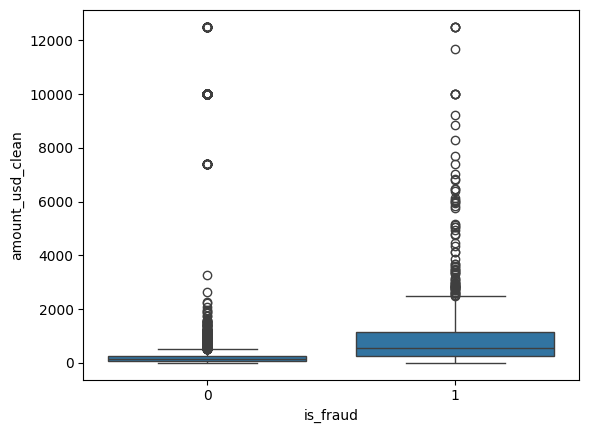

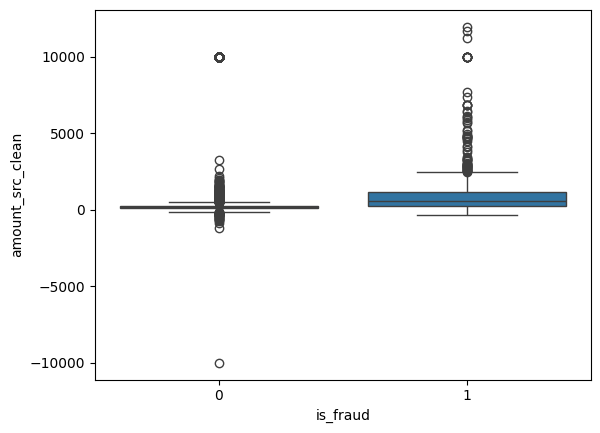

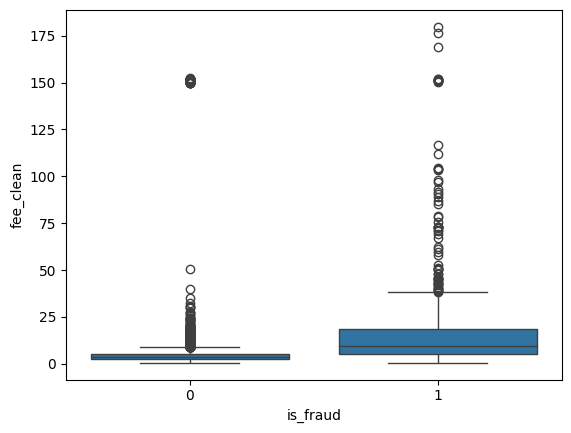

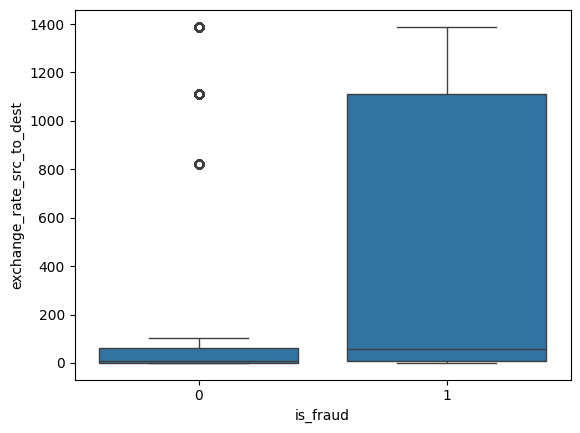

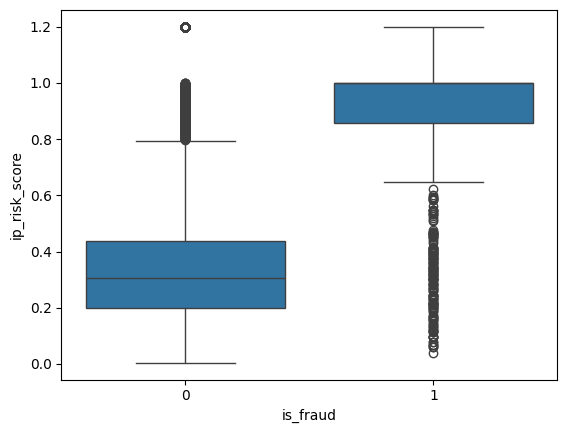

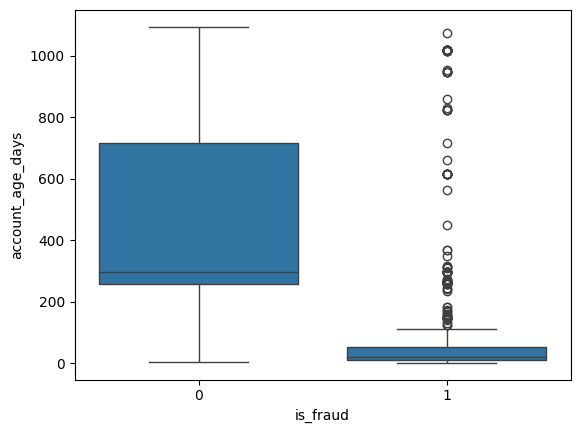

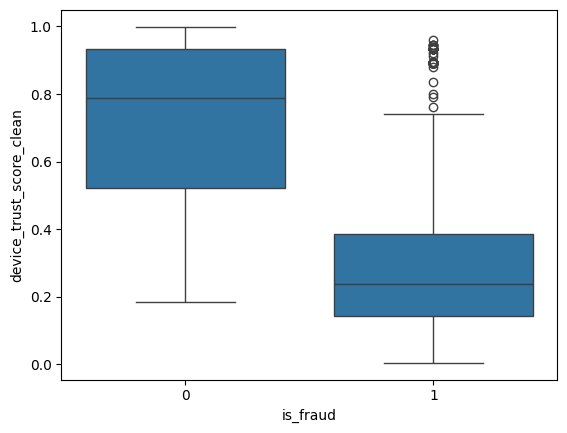

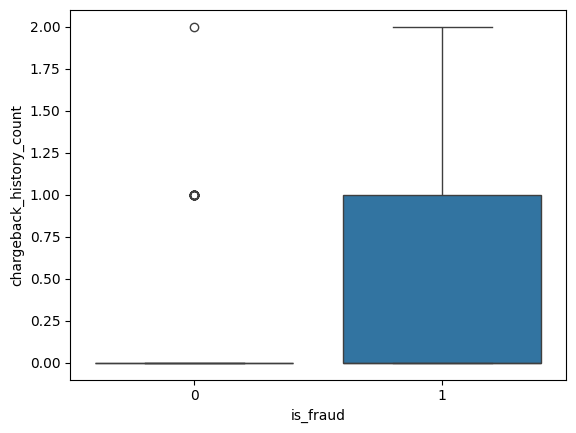

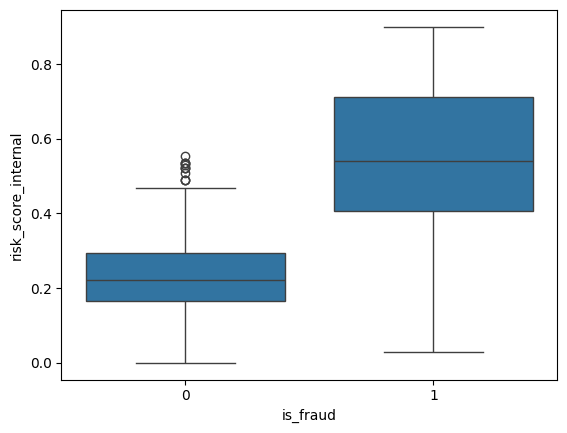

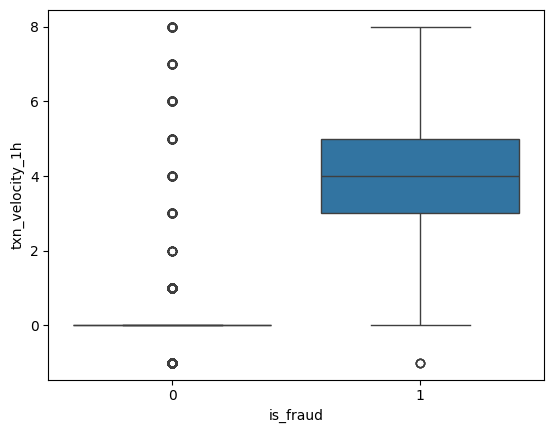

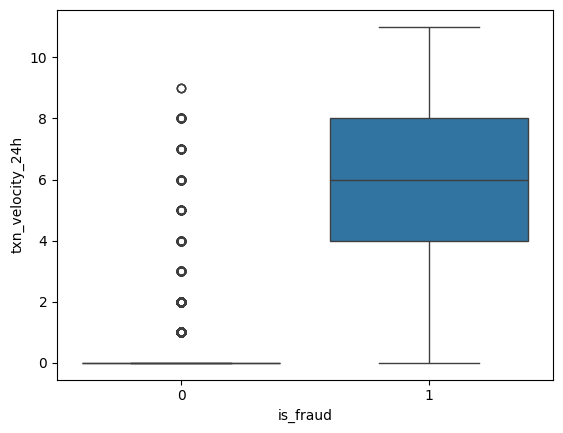

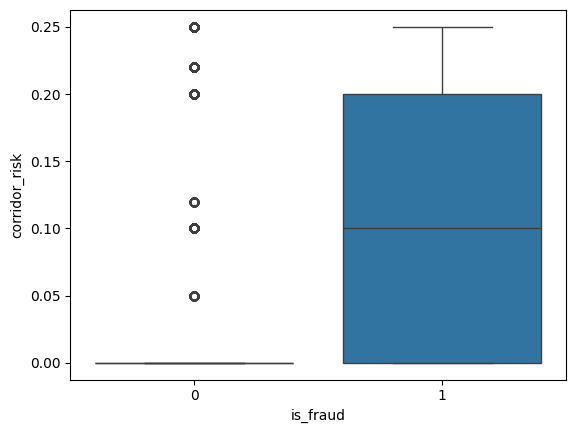

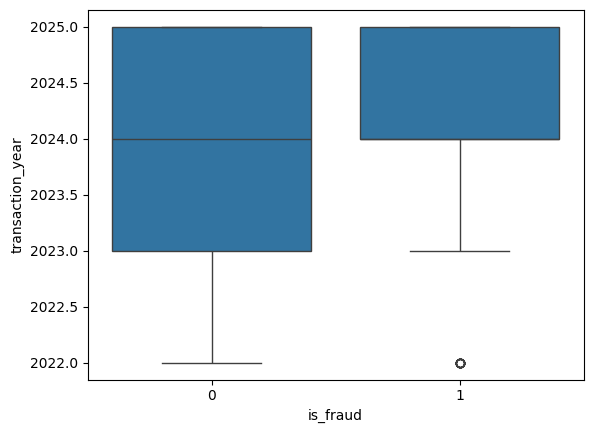

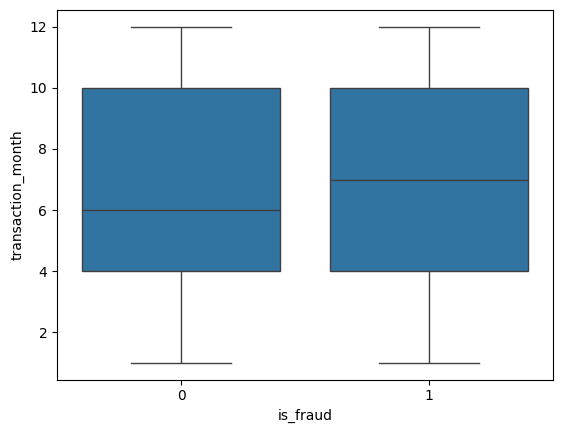

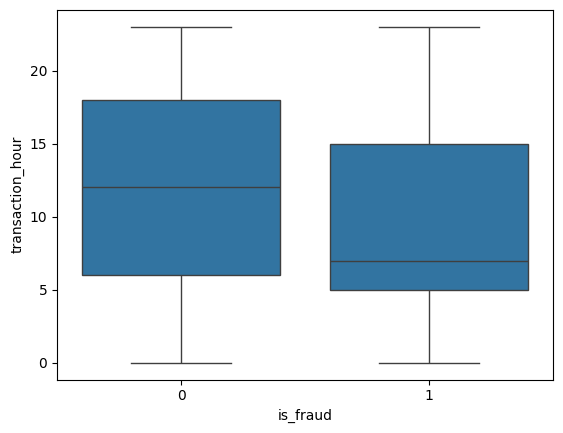

In [422]:
for col in data_cleaned.drop('is_fraud', axis=1).select_dtypes('number'):
    sns.boxplot(data=data_cleaned, x ='is_fraud', y =col)
    plt.show()

 - From the quick view of the target variable versus the numerical features show that we have alot of promising features that may have predictive power of predicting whether the transaction is fraud or not. 
 
 - Although some features like transaction month does not seem to be have any promising impact on whether a transaction is fraud or not. We look into this very well

##### What is the distribution of fraud vs the Categorical features?
just a qucik view of the categorical features

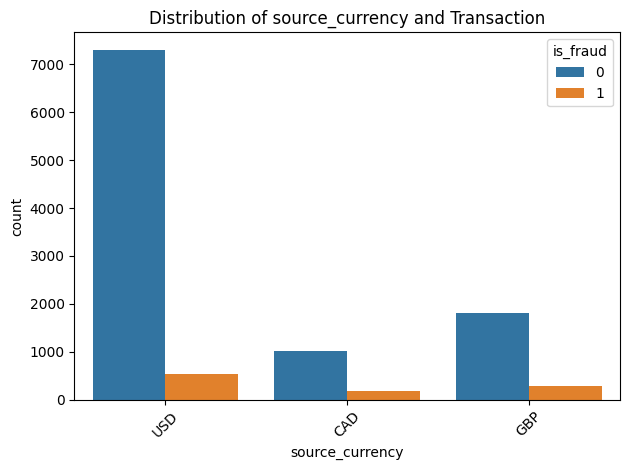

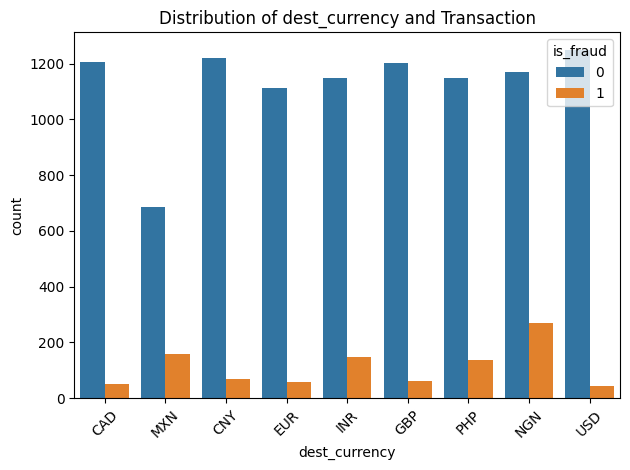

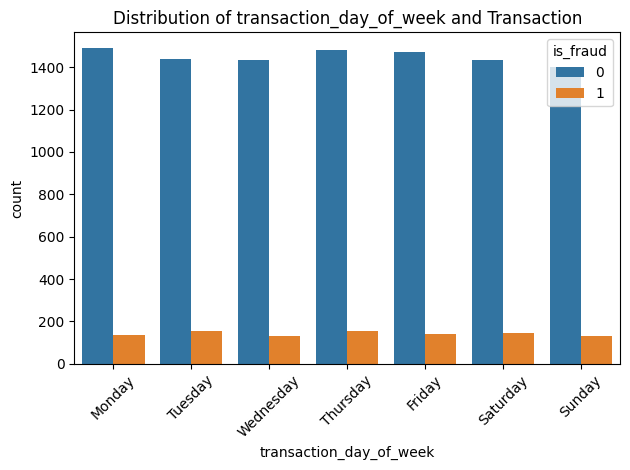

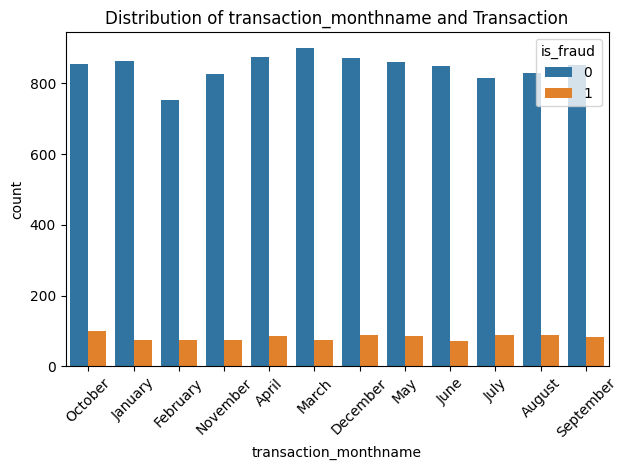

In [423]:
    for col in data_cleaned.drop('is_fraud', axis=1).select_dtypes('object'):
        sns.countplot(data=data_cleaned, x=col, hue='is_fraud')
        plt.title(f"Distribution of {col} and Transaction")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    plt.show()

In [434]:
fraud_labels = {
    0: "Legitimate",
    1: "Fraud"
}

data_cleaned["fraud_status"] = (
    data_cleaned["is_fraud"].map(fraud_labels)
)

In [435]:
data_cleaned.head(2)

,timestamp_clean,home_country_clean,source_currency,dest_currency,channel,amount_usd_clean,amount_src_clean,fee_clean,exchange_rate_src_to_dest,new_device,...,corridor_risk,transaction_year,transaction_month,transaction_hour,transaction_day_of_week,is_weekend,is_night_transaction,is_fraud,transaction_monthname,fraud_status
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,...,0.0,2022,10,18,Monday,False,False,0,October,Legitimate
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,154.29,208.51,4.24,12.758621,True,...,0.0,2022,10,20,Monday,False,False,0,October,Legitimate


#### What is the distribution of fraud

Legitimate (0): 10,147 (91.1%)
Fraudulent(1): 993 (8.9%)


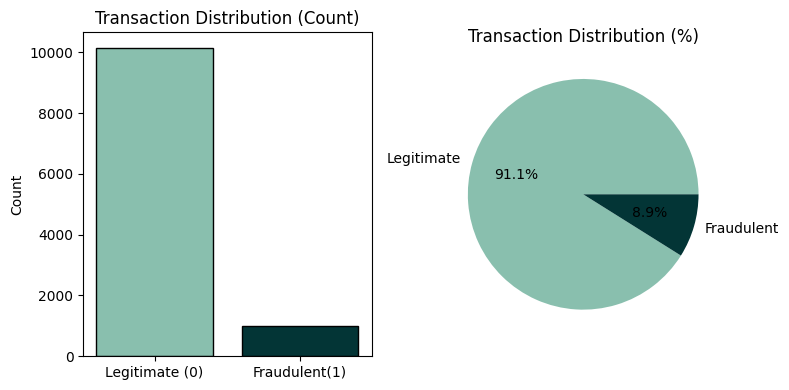

In [447]:
colors = ["#89BFAE", "#033536"]
fraud_counts = data_cleaned['is_fraud'].value_counts()
fraud_pct = data_cleaned['is_fraud'].value_counts(normalize=True) * 100

print(f"Legitimate (0): {fraud_counts[0]:,} ({fraud_pct[0]:.1f}%)")
print(f"Fraudulent(1): {fraud_counts[1]:,} ({fraud_pct[1]:.1f}%)")

# Visualize

#BAR CHART
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].bar(['Legitimate (0)', 'Fraudulent(1)'], fraud_counts.values, color=["#89BFAE", "#033536"], edgecolor='black')
axes[0].set_title('Transaction Distribution (Count)')
axes[0].set_ylabel('Count')

#PIE CHART
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraudulent'], autopct='%1.1f%%', colors=["#89BFAE", "#033536"])
axes[1].set_title('Transaction Distribution (%)')

plt.tight_layout()
plt.show()

- It clearly that we have the imbalance problem, with over 91% of none fraud transaction and 8.9% of fraud cases

 #### How fraudlent transaction has evolve over time

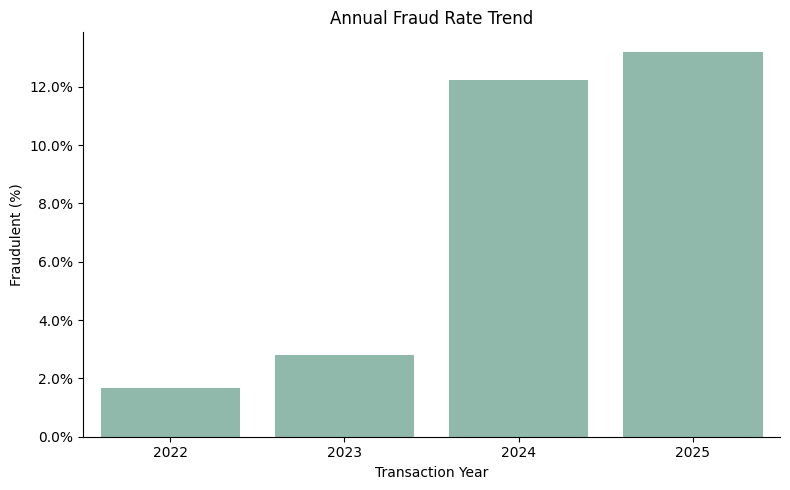

In [425]:
# Q1: How fraudlent transaction has evolve over time

# Calculate annual fraud rate
fraud_trend = (
    data_cleaned
    .groupby("transaction_year")["is_fraud"]
    .mean()
    .reset_index(name="fraud_rate")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=fraud_trend,
    x="transaction_year",
    y="fraud_rate",
    color="#89BFAE"
)

plt.title(
    "Annual Fraud Rate Trend")

plt.xlabel("Transaction Year")
plt.ylabel("Fraudulent (%)")

# Display y-axis as percentages
import matplotlib.ticker as mtick

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
sns.despine()
plt.tight_layout()
plt.show()

 #### What is the financial impact of fraud on Nova Pay's fee?

Fraud: 16,041.07 (18.84%)
Legitimate: 69,088.68 (81.16%)


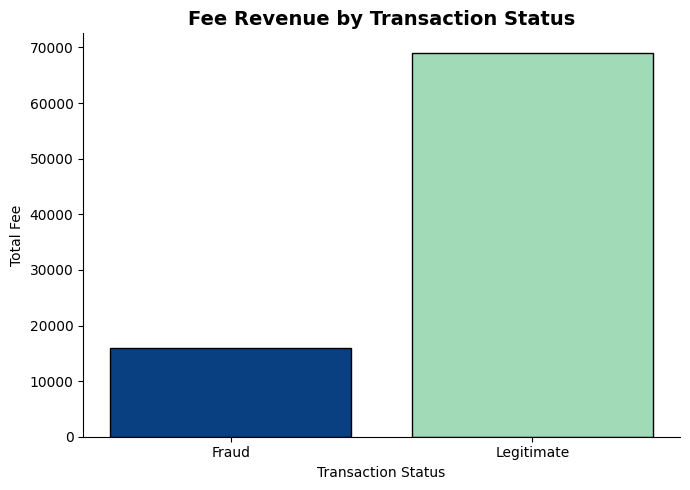

In [446]:
# Total fee summary by transaction status
fee_summary = (
    data_cleaned
    .groupby("fraud_status")["fee_clean"]
    .sum()
    .reset_index()
)

fee_summary.columns = ["fraud_status", "total_fee"]

# Calculate percentage contribution
total = fee_summary["total_fee"].sum()

fee_summary["percentage"] = (
    fee_summary["total_fee"] / total * 100
).round(2)

# Print the results
for _, row in fee_summary.iterrows():
    print(
        f"{row['fraud_status']}: "
        f"{row['total_fee']:,.2f} "
        f"({row['percentage']}%)"
    )



plt.figure(figsize=(7, 5))

colors = ["#084081", "#a1dab7"]

plt.bar(
    fee_summary["fraud_status"],
    fee_summary["total_fee"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Fee Revenue by Transaction Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Transaction Status")
plt.ylabel("Total Fee")

plt.xticks(rotation=0)

sns.despine()
plt.tight_layout()
plt.show()

- The analysis show that fee Nova Pay lost by Fraud is $16,041.07 which is about 19% while Legitimate transacton generated about  $69,088.68 that approximatley 81%.

#### What is the overall fraud prevalence?

In [454]:
fraud_summary = (
    data_cleaned["fraud_status"]
    .value_counts()
    .rename_axis("transaction_status")
    .reset_index(name="transaction_count")
)

fraud_summary["percentage"] = (
    fraud_summary["transaction_count"]
    / fraud_summary["transaction_count"].sum()
    * 100
).round(2)

fraud_summary

,transaction_status,transaction_count,percentage
0,Legitimate,10147,91.09
1,Fraud,993,8.91


#### How has fraud evolved over time?

In [455]:
annual_fraud = (
    data_cleaned
    .groupby("transaction_year")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

annual_fraud["fraud_rate_pct"] = (
    annual_fraud["fraud_rate"] * 100
)

annual_fraud

,transaction_year,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
0,2022,781,13,0.016645,1.664533
1,2023,3354,94,0.028026,2.802624
2,2024,3938,481,0.122143,12.214322
3,2025,3067,405,0.132051,13.205086


#### What is the monetary exposure associated with fraud?

In [458]:
financial_summary = (
    data_cleaned
    .groupby("fraud_status")
    .agg(
        transaction_count=("home_country_clean", "count"),
        total_value_usd=("amount_usd_clean", "sum"),
        average_value_usd=("amount_usd_clean", "mean"),
        median_value_usd=("amount_usd_clean", "median"),
        maximum_value_usd=("amount_usd_clean", "max")
    )
    .reset_index()
)

financial_summary

,fraud_status,transaction_count,total_value_usd,average_value_usd,median_value_usd,maximum_value_usd
0,Fraud,993,1019675.43,1026.863474,545.20,12496.24
1,Legitimate,10147,3975837.50,391.823938,151.67,12498.58


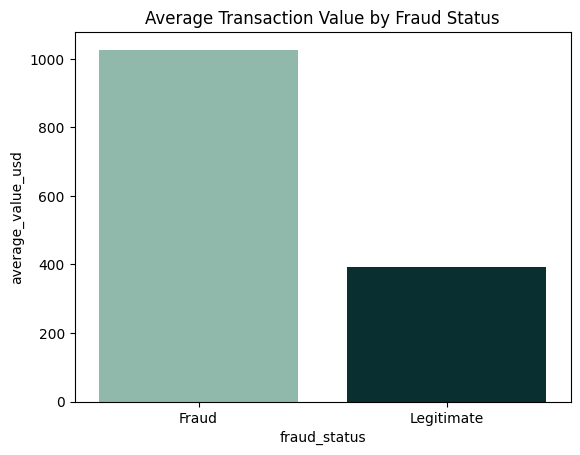

In [491]:
colors = ["#89BFAE", "#033536"]
sns.barplot(data=financial_summary, x='fraud_status', y='average_value_usd', palette=colors)
plt.title('Average Transaction Value by Fraud Status')
plt.show()

- Fraudulent transaction has huge financial impact on Nova Pay

#### Does transaction amount influence fraud risk?

In [460]:
data_cleaned["amount_band"] = pd.cut(
    data_cleaned["amount_usd_clean"],
    bins=[0, 100, 250, 500, 1000, 2500, float("inf")],
    labels=[
        "$0–$100",
        "$101–$250",
        "$251–$500",
        "$501–$1,000",
        "$1,001–$2,500",
        "Above $2,500"
    ],
    include_lowest=True
)

amount_risk = (
    data_cleaned
    .groupby("amount_band", observed=False)
    .agg(
        transactions=("is_fraud", "size"),
        fraud_cases=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

amount_risk["fraud_rate_pct"] = (
    amount_risk["fraud_rate"] * 100
).round(2)

amount_risk

,amount_band,transactions,fraud_cases,fraud_rate,fraud_rate_pct
0,$0–$100,3113,58,0.018632,1.86
1,$101–$250,4493,167,0.037169,3.72
2,$251–$500,2122,234,0.110273,11.03
3,"$501–$1,000",835,241,0.288623,28.86
4,"$1,001–$2,500",306,215,0.702614,70.26
5,"Above $2,500",271,78,0.287823,28.78


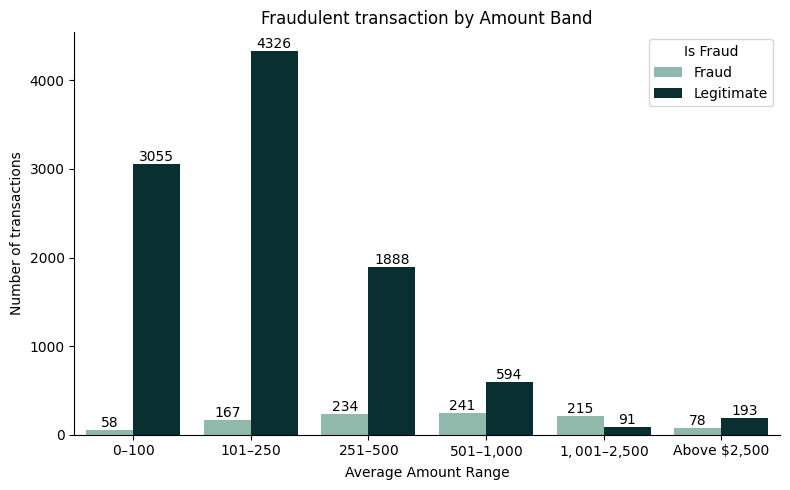

In [495]:
# Count canceled and not canceled per price range
price_status = data_cleaned.groupby(['amount_band', 'fraud_status']).size().reset_index(name='count')

# Bar chart - Canceled vs Not Canceled side by side per price range
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=price_status, x='amount_band', y='count', hue='fraud_status', palette=("#89BFAE", "#033536"))

for container in ax.containers: ax.bar_label(container, fmt='%.0f')

plt.title('Fraudulent transaction by Amount Band')
plt.xlabel('Average Amount Range')
plt.ylabel('Number of transactions')
plt.legend(title='Is Fraud')
sns.despine()
plt.tight_layout()
plt.show()

- Nova Pay experince a lot of fraudulent transaction with the amount range of $501 - $2500. This means more transaction amount may invite more attention

In [492]:
data_cleaned.head()

,timestamp_clean,home_country_clean,source_currency,dest_currency,channel,amount_usd_clean,amount_src_clean,fee_clean,exchange_rate_src_to_dest,new_device,...,is_weekend,is_night_transaction,is_fraud,transaction_monthname,fraud_status,amount_band,currency_corridor,device_trust_band,account_age_band,velocity_1h_band
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,...,False,False,0,October,Legitimate,$251–$500,USD → CAD,Moderate Trust,181–365 days,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,154.29,208.51,4.24,12.758621,True,...,False,False,0,October,Legitimate,$101–$250,CAD → MXN,Low Trust,Above 2 years,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,False,...,False,False,0,October,Legitimate,$101–$250,USD → CNY,High Trust,1–2 years,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,False,...,False,True,0,October,Legitimate,$0–$100,USD → EUR,Moderate Trust,91–180 days,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,False,...,False,False,0,October,Legitimate,$101–$250,USD → INR,High Trust,181–365 days,0


####  Which transaction channel has the highest fraud risk?

In [461]:
channel_analysis = (
    data_cleaned
    .groupby("channel")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
        fraud_value_usd=(
            "amount_usd_clean",
            lambda x: x[
                data_cleaned.loc[x.index, "is_fraud"] == 1
            ].sum()
        )
    )
    .reset_index()
)

channel_analysis["fraud_rate_pct"] = (
    channel_analysis["fraud_rate"] * 100
).round(2)

.sort_values(
    "fraud_rate_pct",
    ascending=False
)

,channel,total_transactions,fraud_transactions,fraud_rate,fraud_value_usd,fraud_rate_pct
3,web,3749,613,0.163510,618090.71,16.35
0,ATM,996,81,0.081325,85222.23,8.13
1,mobile,6358,298,0.046870,315973.52,4.69
2,unknown,37,1,0.027027,388.97,2.70


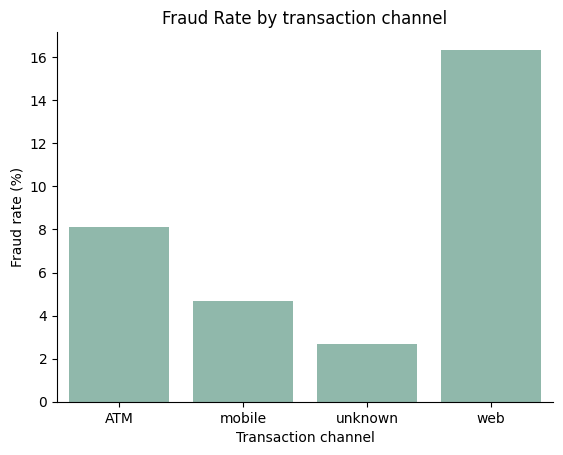

In [498]:
sns.barplot(data =channel_analysis, x='channel', y='fraud_rate_pct', color ="#89BFAE")
plt.title('Fraud Rate by transaction channel')
plt.xlabel('Transaction channel')
plt.ylabel('Fraud rate (%)')
sns.despine()
plt.show()

####  Does geographic mismatch increase fraud risk?

In [462]:
location_analysis = (
    data_cleaned
    .groupby("location_mismatch")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

location_analysis["fraud_rate_pct"] = (
    location_analysis["fraud_rate"] * 100
).round(2)

location_analysis

,location_mismatch,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
0,False,9322,336,0.036044,3.60
1,True,1818,657,0.361386,36.14


In [463]:
location_analysis["location_status"] = (
    location_analysis["location_mismatch"]
    .map({
        False: "Location Match",
        True: "Location Mismatch"
    })
)

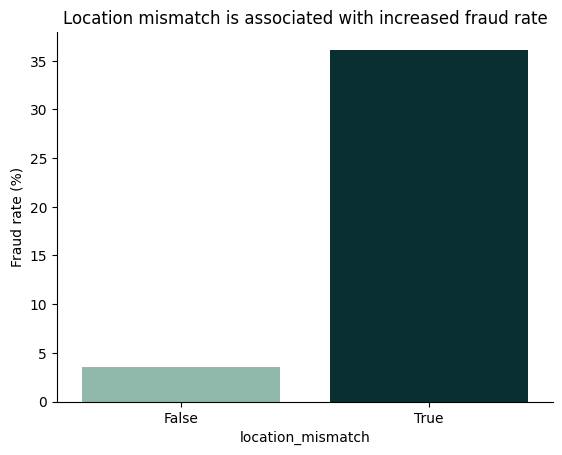

In [500]:
sns.barplot(data =location_analysis, x='location_mismatch', y='fraud_rate_pct', palette=colors)
plt.title('Location mismatch is associated with increased fraud rate')
plt.xlabel('location_mismatch')
plt.ylabel('Fraud rate (%)')
sns.despine()
plt.show()

- A transaction with mismatch location has a high fraud rate

#### Which countries have the highest fraud exposure?

In [464]:
country_analysis = (
    data_cleaned
    .groupby("home_country_clean")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
        total_value_usd=("amount_usd_clean", "sum")
    )
    .reset_index()
)

country_analysis["fraud_rate_pct"] = (
    country_analysis["fraud_rate"] * 100
).round(2)

country_analysis.sort_values(
    "fraud_rate_pct",
    ascending=False
)

,home_country_clean,total_transactions,fraud_transactions,fraud_rate,total_value_usd,fraud_rate_pct
0,CA,1208,185,0.153146,458055.15,15.31
1,UK,2099,280,0.133397,1127490.01,13.34
2,US,7833,528,0.067407,3409967.77,6.74


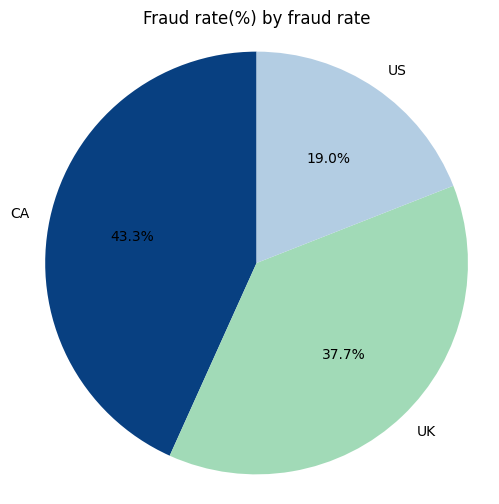

In [504]:
plt.figure(figsize=(6, 6))
plt.pie(
    country_analysis["fraud_rate_pct"],
    labels=country_analysis["home_country_clean"],
    autopct="%1.1f%%",
    colors=["#084081", "#a1dab7", "#b3cde3", "#f4a582", "#80cdc1", "#dfc27d"],
    startangle=90
)
plt.title("Fraud rate(%) by fraud rate")
plt.axis("equal")
plt.show()

- Canada show the countries with the highest fraud rate of about 43.3% followed by United Kingdom

#### Which transfer corridors are most vulnerable?

In [465]:
data_cleaned["currency_corridor"] = (
    data_cleaned["source_currency"]
    + " → "
    + data_cleaned["dest_currency"]
)

corridor_analysis = (
    data_cleaned
    .groupby("currency_corridor")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
        total_value_usd=("amount_usd_clean", "sum"),
        fraud_value_usd=(
            "amount_usd_clean",
            lambda x: x[
                data_cleaned.loc[x.index, "is_fraud"] == 1
            ].sum()
        )
    )
    .reset_index()
)

corridor_analysis["fraud_rate_pct"] = (
    corridor_analysis["fraud_rate"] * 100
).round(2)

reliable_corridors = corridor_analysis[
    corridor_analysis["total_transactions"] >= 30
].sort_values(
    "fraud_rate_pct",
    ascending=False
)

reliable_corridors.head(10)

,currency_corridor,total_transactions,fraud_transactions,fraud_rate,total_value_usd,fraud_value_usd,fraud_rate_pct
4,CAD → INR,176,107,0.607955,99721.72,75502.22,60.80
15,GBP → NGN,310,122,0.393548,251257.35,179639.70,39.35
23,USD → MXN,486,129,0.265432,222483.11,124340.90,26.54
11,GBP → EUR,136,20,0.147059,73133.22,32700.42,14.71
24,USD → NGN,1008,134,0.132937,480286.03,143155.75,13.29
6,CAD → NGN,124,15,0.120968,56103.17,26170.98,12.10
25,USD → PHP,935,112,0.119786,441011.33,110199.14,11.98
10,GBP → CNY,252,25,0.099206,97467.05,25691.42,9.92
17,GBP → USD,240,22,0.091667,124011.94,18051.13,9.17
12,GBP → GBP,237,21,0.088608,123560.90,13148.63,8.86


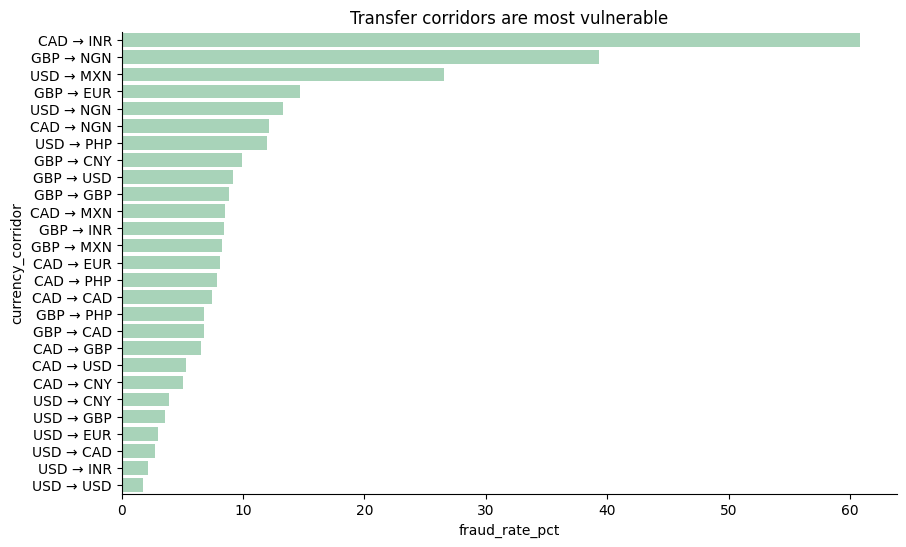

In [513]:
plt.figure(figsize=(10,6))
sns.barplot(data=reliable_corridors, y='currency_corridor', x ='fraud_rate_pct', color ="#a1dab7")
plt.title('Transfer corridors are most vulnerable')
sns.despine()
plt.show()

- The most vulnerable financial risk is from CAD to NGN with over 61% fraud rate

In [505]:
data_cleaned.head()

,timestamp_clean,home_country_clean,source_currency,dest_currency,channel,amount_usd_clean,amount_src_clean,fee_clean,exchange_rate_src_to_dest,new_device,...,is_weekend,is_night_transaction,is_fraud,transaction_monthname,fraud_status,amount_band,currency_corridor,device_trust_band,account_age_band,velocity_1h_band
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,...,False,False,0,October,Legitimate,$251–$500,USD → CAD,Moderate Trust,181–365 days,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,154.29,208.51,4.24,12.758621,True,...,False,False,0,October,Legitimate,$101–$250,CAD → MXN,Low Trust,Above 2 years,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,False,...,False,False,0,October,Legitimate,$101–$250,USD → CNY,High Trust,1–2 years,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,False,...,False,True,0,October,Legitimate,$0–$100,USD → EUR,Moderate Trust,91–180 days,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,False,...,False,False,0,October,Legitimate,$101–$250,USD → INR,High Trust,181–365 days,0


#### Are new devices associated with more fraud?

In [468]:
data_cleaned["device_trust_band"] = pd.cut(
    data_cleaned["device_trust_score_clean"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "Very Low Trust",
        "Low Trust",
        "Moderate Trust",
        "High Trust"
    ],
    include_lowest=True
)

device_trust_analysis = (
    data_cleaned
    .groupby("device_trust_band", observed=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

device_trust_analysis["fraud_rate_pct"] = (
    device_trust_analysis["fraud_rate"] * 100
).round(2)

device_trust_analysis

,device_trust_band,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
0,Very Low Trust,611,518,0.847791,84.78
1,Low Trust,1939,294,0.151625,15.16
2,Moderate Trust,3229,68,0.021059,2.11
3,High Trust,5361,113,0.021078,2.11


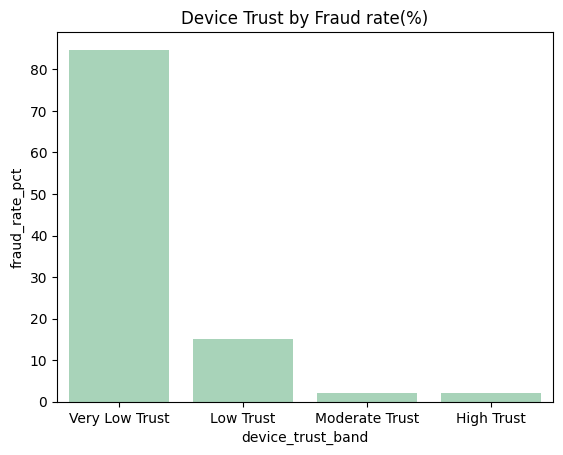

In [516]:
sns.barplot(data =device_trust_analysis, x ='device_trust_band', y ='fraud_rate_pct', color ="#a1dab7")
plt.title('Device Trust by Fraud rate(%)')
plt.show()


- Nova Pay should take note that very low Trust device is associated high fraud rate. Over 85% fraud rate is associated with very low trust device

#### Does KYC verification reduce fraud risk?

In [467]:
kyc_analysis = (
    data_cleaned
    .groupby("kyc_tier_clean")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

kyc_analysis["fraud_rate_pct"] = (
    kyc_analysis["fraud_rate"] * 100
).round(2)

kyc_analysis.sort_values(
    "fraud_rate_pct",
    ascending=False
)

,kyc_tier_clean,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
1,low,1054,536,0.508539,50.85
2,standard,8193,416,0.050775,5.08
0,enhanced,1891,41,0.021682,2.17
3,unknown,2,0,0.000000,0.00


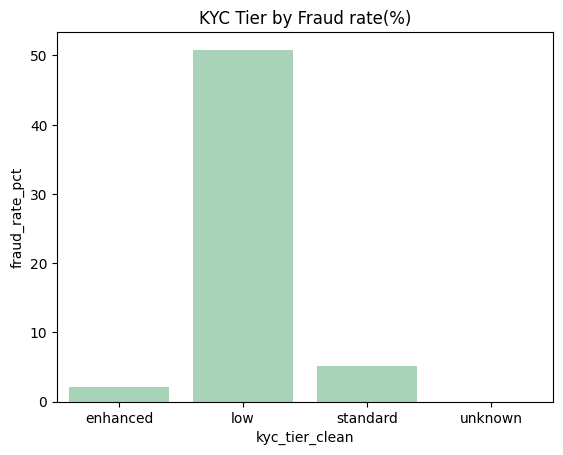

In [518]:
sns.barplot(data =kyc_analysis, x ='kyc_tier_clean', y ='fraud_rate_pct', color ="#a1dab7")
plt.title('KYC Tier by Fraud rate(%)')
plt.show()

- Low tier KYC customers are the most fraudulent prone customers

#### Are newer accounts more vulnerable?

In [524]:
data_cleaned["account_age_band"] = pd.cut(
    data_cleaned["account_age_days"],
    bins=[0, 30, 90, 180, 365, 730, float("inf")],
    labels=[
        "0–30 days",
        "31–90 days",
        "91–180 days",
        "181–365 days",
        "1–2 years",
        "Above 2 years"
    ],
    include_lowest=True
)

account_age_analysis = (
    data_cleaned
    .groupby("account_age_band", observed=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

account_age_analysis["fraud_rate_pct"] = (
    account_age_analysis["fraud_rate"] * 100
).round(2)

account_age_analysis

,account_age_band,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
0,0–30 days,1900,676,0.355789,35.58
1,31–90 days,425,186,0.437647,43.76
2,91–180 days,993,25,0.025176,2.52
3,181–365 days,3601,61,0.016940,1.69
4,1–2 years,1927,15,0.007784,0.78
5,Above 2 years,2294,30,0.013078,1.31


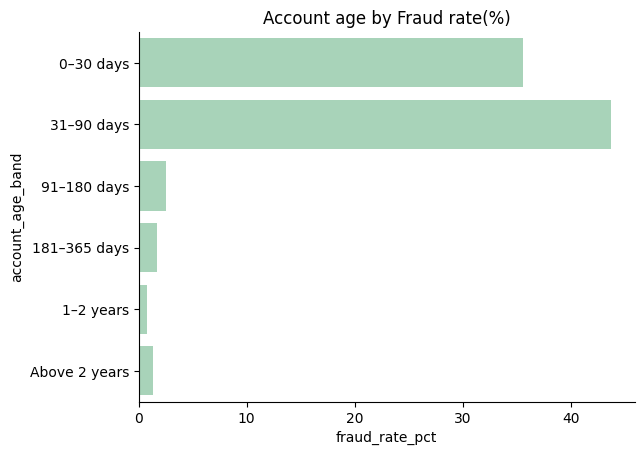

In [525]:
sns.barplot(data =account_age_analysis, y='account_age_band', x ='fraud_rate_pct', color ="#a1dab7")
plt.title('Account age by Fraud rate(%)')
sns.despine()
plt.show()

- Account age with 0-90 days are the most exposed to fraud rate activities

#### Does rapid transaction activity indicate fraud?

In [473]:
velocity_analysis = (
    data_cleaned
    .groupby("txn_velocity_1h")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

velocity_analysis["fraud_rate_pct"] = (
    velocity_analysis["fraud_rate"] * 100
).round(2)
velocity_analysis[1:]

,txn_velocity_1h,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
1,0,9727,175,0.017991,1.80
2,1,132,0,0.000000,0.00
3,2,18,0,0.000000,0.00
4,3,262,219,0.835878,83.59
5,4,242,203,0.838843,83.88
6,5,189,153,0.809524,80.95
7,6,169,119,0.704142,70.41
8,7,113,78,0.690265,69.03
9,8,88,42,0.477273,47.73


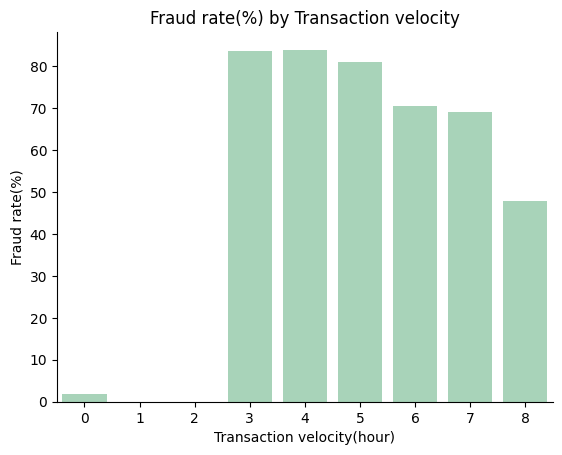

In [532]:
sns.barplot(data =velocity_analysis[1:], x ='txn_velocity_1h', y ='fraud_rate_pct', color ="#a1dab7")
plt.title('Fraud rate(%) by Transaction velocity')
plt.ylabel('Fraud rate(%)')
plt.xlabel('Transaction velocity(hour)')
sns.despine()
plt.show()

#### Does chargeback history predict fraud?

In [476]:
chargeback_analysis = (
    data_cleaned
    .groupby("chargeback_history_count")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

chargeback_analysis["fraud_rate_pct"] = (
    chargeback_analysis["fraud_rate"] * 100
).round(2)

chargeback_analysis

,chargeback_history_count,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
0,0,10699,576,0.053837,5.38
1,1,330,307,0.930303,93.03
2,2,111,110,0.990991,99.10


#### How do the risk scores differ between fraud and legitimate transactions?

In [477]:
risk_score_summary = (
    data_cleaned
    .groupby("fraud_status")
    [[
        "ip_risk_score",
        "risk_score_internal",
        "corridor_risk",
        "device_trust_score_clean"
    ]]
    .agg(["mean", "median"])
)

risk_score_summary

ip_risk_score        risk_score_internal        corridor_risk  \
                      mean median                mean median          mean   
fraud_status                                                                 
Fraud             0.852314  1.000            0.545354  0.541       0.09858   
Legitimate        0.353318  0.307            0.240572  0.223       0.04026   

                    device_trust_score_clean         
             median                     mean median  
fraud_status                                         
Fraud           0.1                 0.316502  0.238  
Legitimate      0.0                 0.704315  0.789

###### When does fraud occur most frequently?

In [538]:
hourly_fraud = (
    data_cleaned
    .groupby("transaction_hour")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

hourly_fraud["fraud_rate_pct"] = (
    hourly_fraud["fraud_rate"] * 100
).round(2)
hourly_fraud.head(2)

,transaction_hour,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
0,0,465,29,0.062366,6.24
1,1,414,26,0.062802,6.28


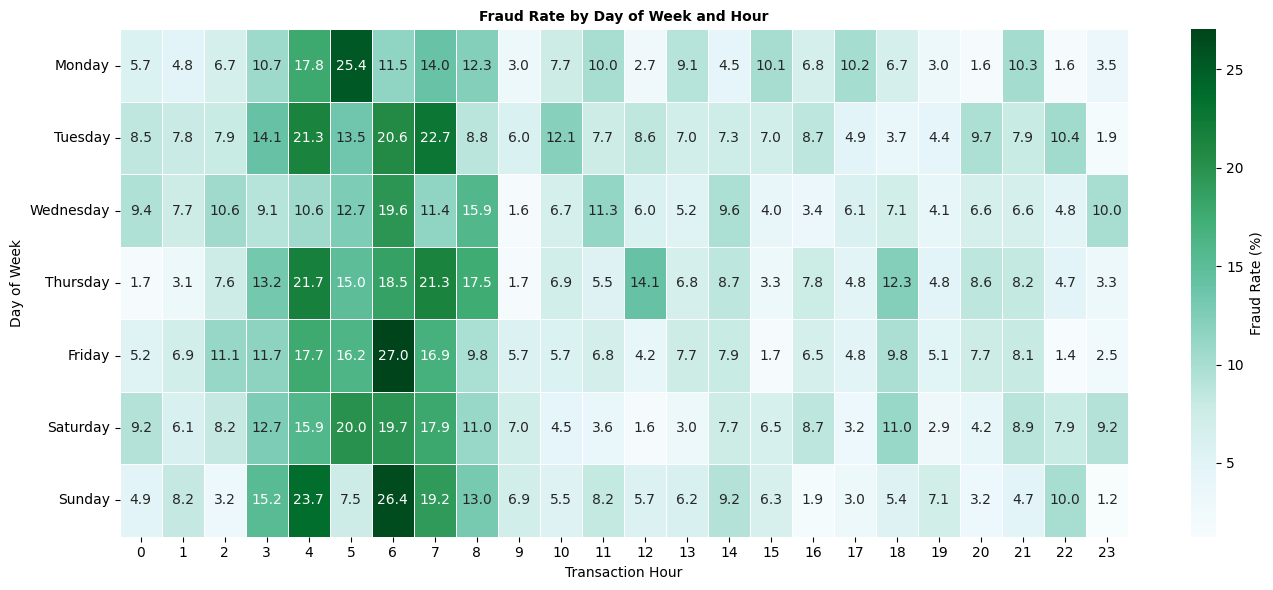

In [539]:
# Ensure proper weekday order
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

data_cleaned["transaction_day_of_week"] = pd.Categorical(
    data_cleaned["transaction_day_of_week"],
    categories=day_order,
    ordered=True
)

# Aggregate fraud rate by day and hour
heatmap_data = (
    data_cleaned
    .groupby(["transaction_day_of_week", "transaction_hour"])
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

heatmap_data["fraud_rate_pct"] = (
    heatmap_data["fraud_rate"] * 100
).round(2)

# Pivot for heatmap
fraud_heatmap = heatmap_data.pivot(
    index="transaction_day_of_week",
    columns="transaction_hour",
    values="fraud_rate_pct"
)

# Plot
plt.figure(figsize=(14, 6))

sns.heatmap(
    fraud_heatmap,
    annot=True,
    fmt=".1f",
    cmap="BuGn",
    linewidths=0.5,
    cbar_kws={"label": "Fraud Rate (%)"}
)

plt.title(
    "Fraud Rate by Day of Week and Hour",
    fontsize=10,
    fontweight="bold"
)
plt.xlabel("Transaction Hour")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

#### Insight

- The heatmap analysis show largely how fraudulent transaction varies across time of the day and day of the weeks.
The fraud rate hits the highest on Monday around 4am, it peaks gradually from 3am and hit over to 25.4% around 4am from 17.8% in 3am.Then drops, this shows unusual activities happen when people are less productive

- Similar pattern show on Tuesday fraudulent activites hit the highest from 4am (21.3%) drop a bit and then peak again around 6am and 7am from 20.6% and 22.7% respectively.

- Same pattern show on Wednesday, while Thursday, Friday, saturday and Sunday show a very different fraud rate of nearly 30%(27%) on Friday around 6am and hit the highest on Sunday(26%) around  6am in the morning. This show factual that fraudulent activities happen around odds of the day especially eary morning hours.

#### Which combinations create the highest risk?

In [481]:
interaction_analysis = (
    data_cleaned
    .groupby(
        ["new_device", "location_mismatch"]
    )
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

interaction_analysis["fraud_rate_pct"] = (
    interaction_analysis["fraud_rate"] * 100
).round(2)

interaction_analysis

,new_device,location_mismatch,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
0,False,False,8477,219,0.025835,2.58
1,False,True,1333,263,0.197299,19.73
2,True,False,845,117,0.138462,13.85
3,True,True,485,394,0.812371,81.24


In [557]:
data_cleaned.head()

,timestamp_clean,home_country_clean,source_currency,dest_currency,channel,amount_usd_clean,amount_src_clean,fee_clean,exchange_rate_src_to_dest,new_device,...,is_weekend,is_night_transaction,is_fraud,transaction_monthname,fraud_status,amount_band,currency_corridor,device_trust_band,account_age_band,velocity_1h_band
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,...,False,False,0,October,Legitimate,$251–$500,USD → CAD,Moderate Trust,181–365 days,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,154.29,208.51,4.24,12.758621,True,...,False,False,0,October,Legitimate,$101–$250,CAD → MXN,Low Trust,Above 2 years,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,False,...,False,False,0,October,Legitimate,$101–$250,USD → CNY,High Trust,1–2 years,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,False,...,False,True,0,October,Legitimate,$0–$100,USD → EUR,Moderate Trust,91–180 days,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,False,...,False,False,0,October,Legitimate,$101–$250,USD → INR,High Trust,181–365 days,0


In [561]:
data_cleaned['is_weekend'].value_counts(normalize =True).reset_index()

,is_weekend,proportion
0,False,0.720826
1,True,0.279174


- Only 27% of the weekend transaction could be flagged as fraudulent

In [562]:
data_cleaned['is_night_transaction'].value_counts(normalize =True).reset_index()

,is_night_transaction,proportion
0,False,0.749461
1,True,0.250539


- Only 25% of the night transaction could be flagged as fraudulent

#### INVESTIGATE AND HANDLE OUTLIERS

##### Investigate outliers with histogram

In [ ]:
numerical_columns = data_cleaned.select_dtypes(include=['number'])

In [548]:
len(numerical_columns.columns)

16

In [545]:
numerical_columns.head()

,amount_usd_clean,amount_src_clean,fee_clean,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score_clean,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,transaction_year,transaction_month,transaction_hour,is_fraud
0,278.19,278.19,4.25,1.351351,0.123,263,0.522,0,0.223,0,0,0.0,2022,10,18,0
1,154.29,208.51,4.24,12.758621,0.569,947,0.475,0,0.268,0,1,0.0,2022,10,20,0
2,160.33,160.33,2.70,7.142857,0.437,367,0.939,0,0.176,0,0,0.0,2022,10,23,0
3,59.41,59.41,2.22,0.925926,0.594,147,0.551,0,0.391,0,0,0.0,2022,10,1,0
4,200.96,200.96,3.61,83.333333,0.121,257,0.894,0,0.257,0,0,0.0,2022,10,9,0


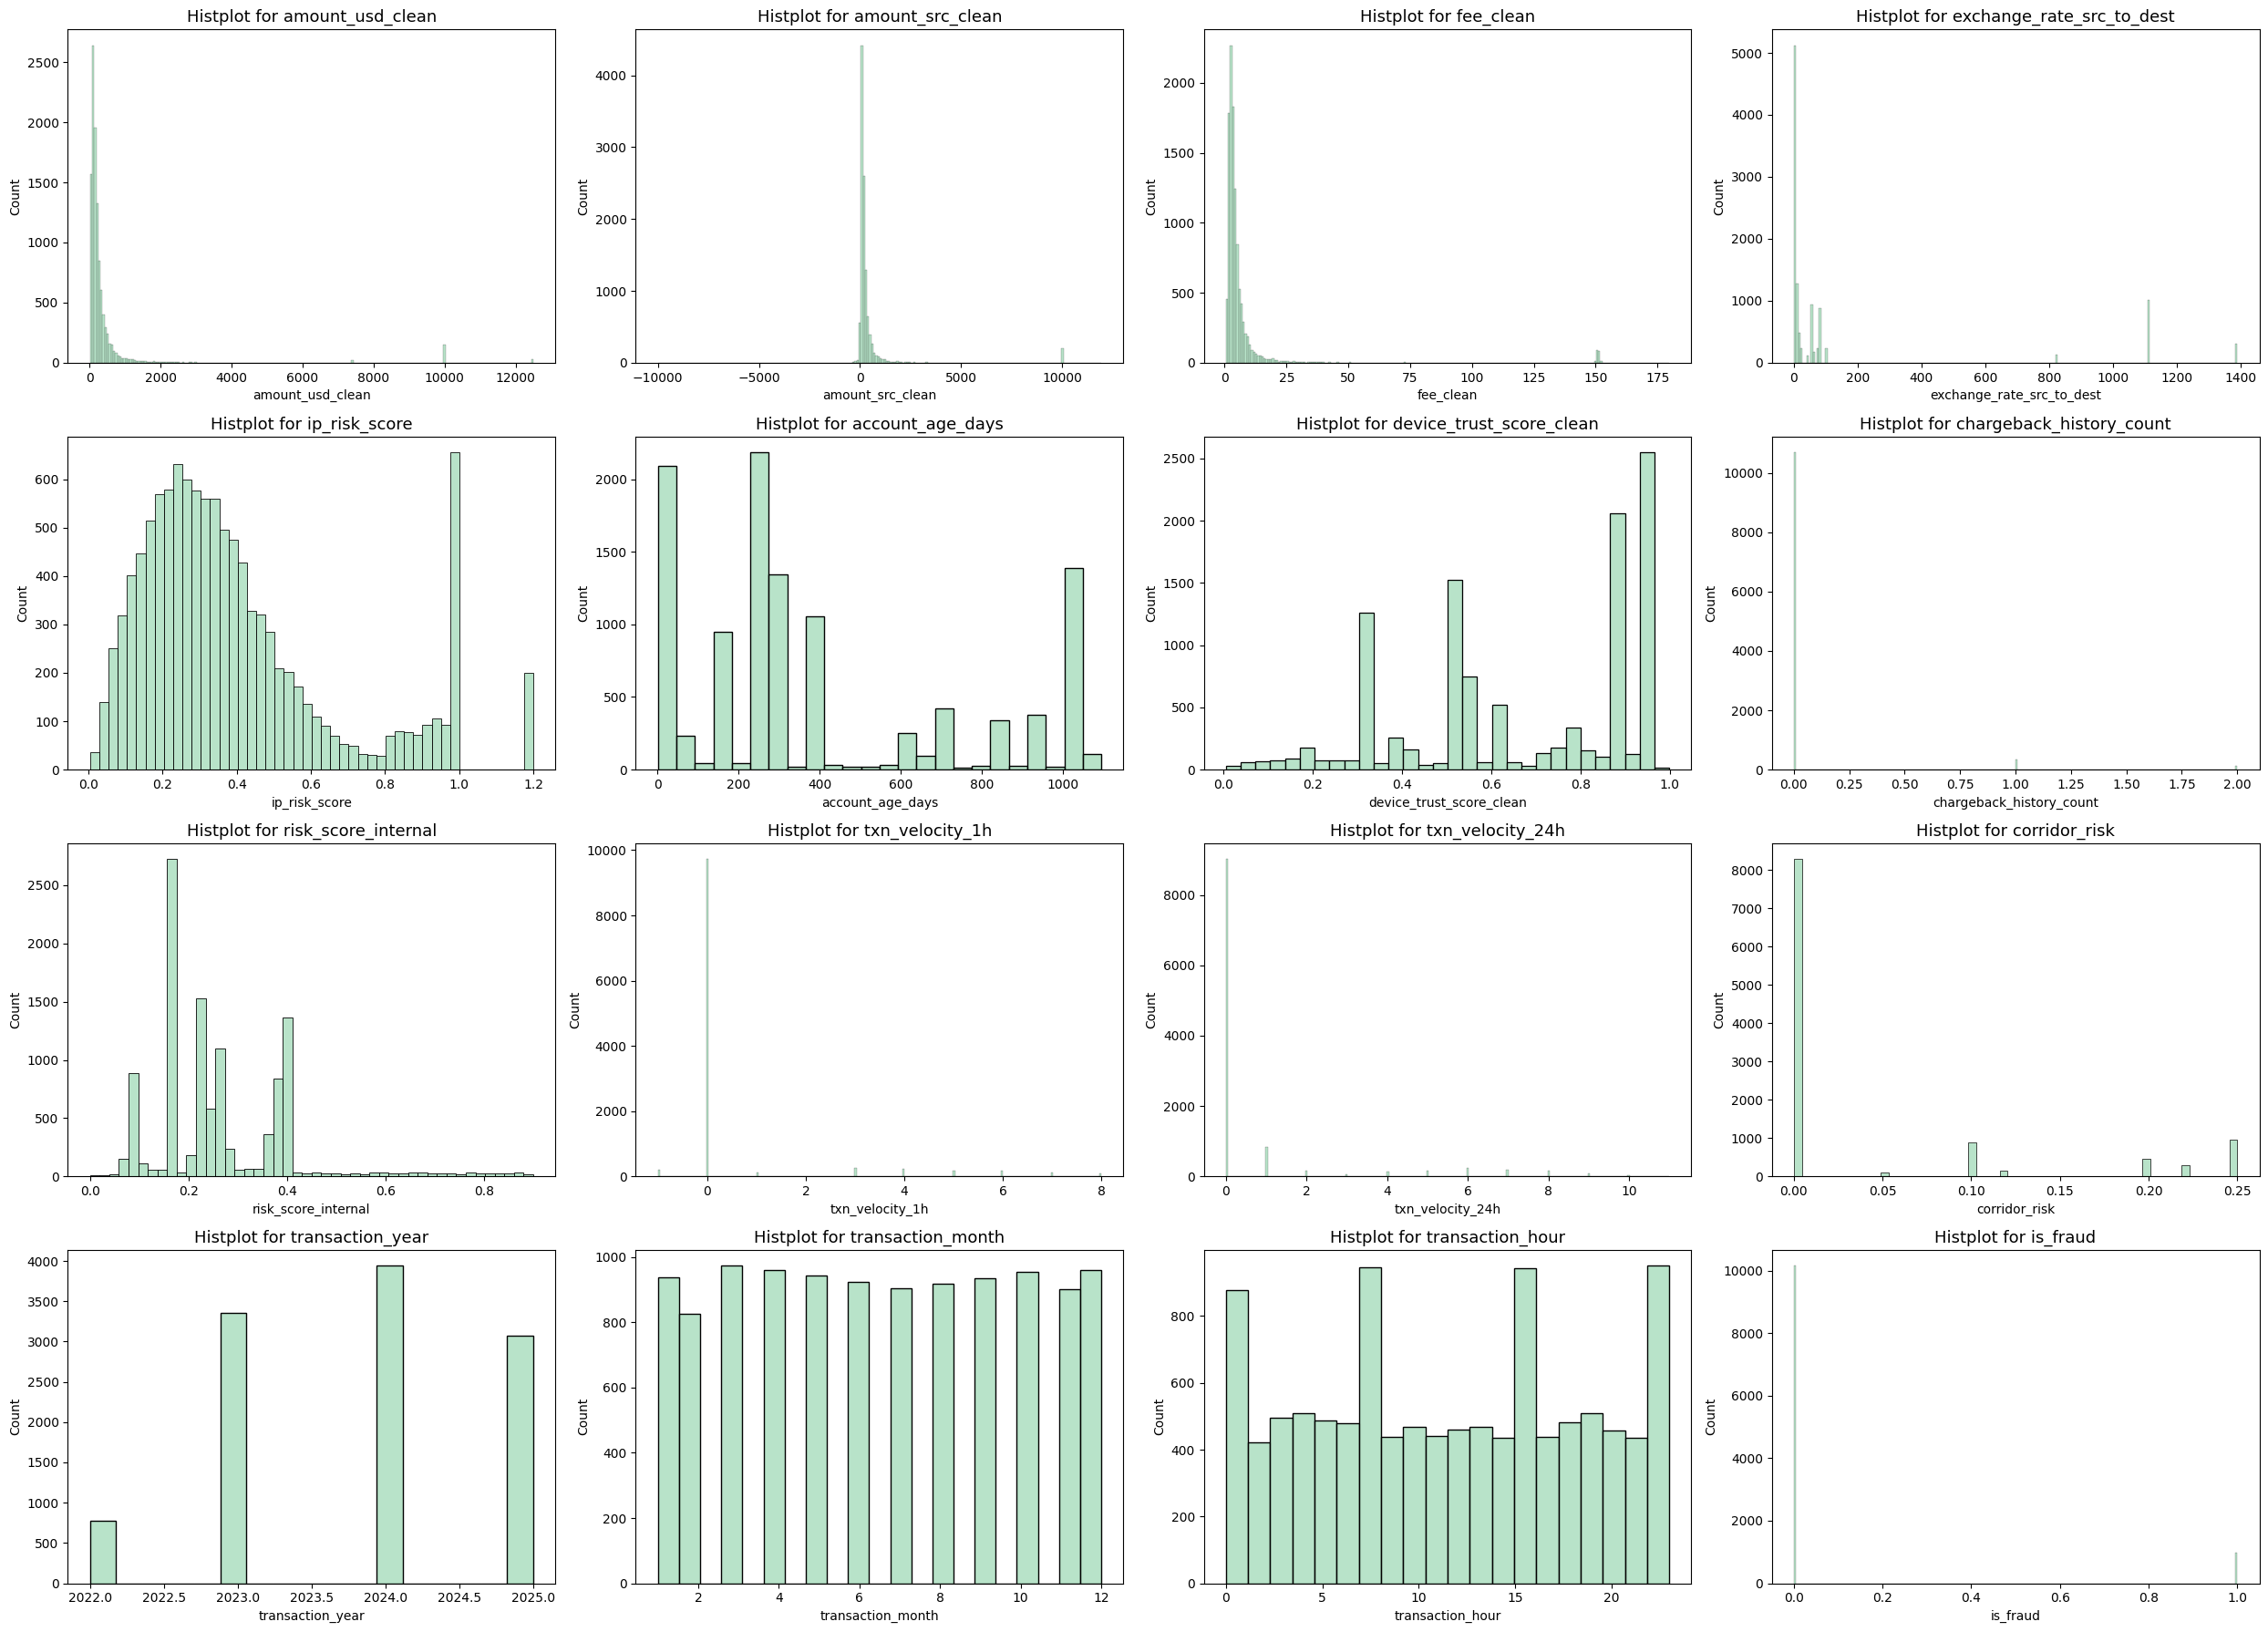

In [549]:
fig, ax = plt.subplots(nrows = 4, ncols = 4, figsize = (25, 18))
ax = ax.flatten()

for idx, col in enumerate (numerical_columns):
    sns.histplot(data[col], ax =ax[idx], color='#a1dab7')
    ax[idx].set_title(f'Histplot for {col}',fontsize=13)

plt.tight_layout()
plt.show()

##### Reconfirm outliers using boxplot

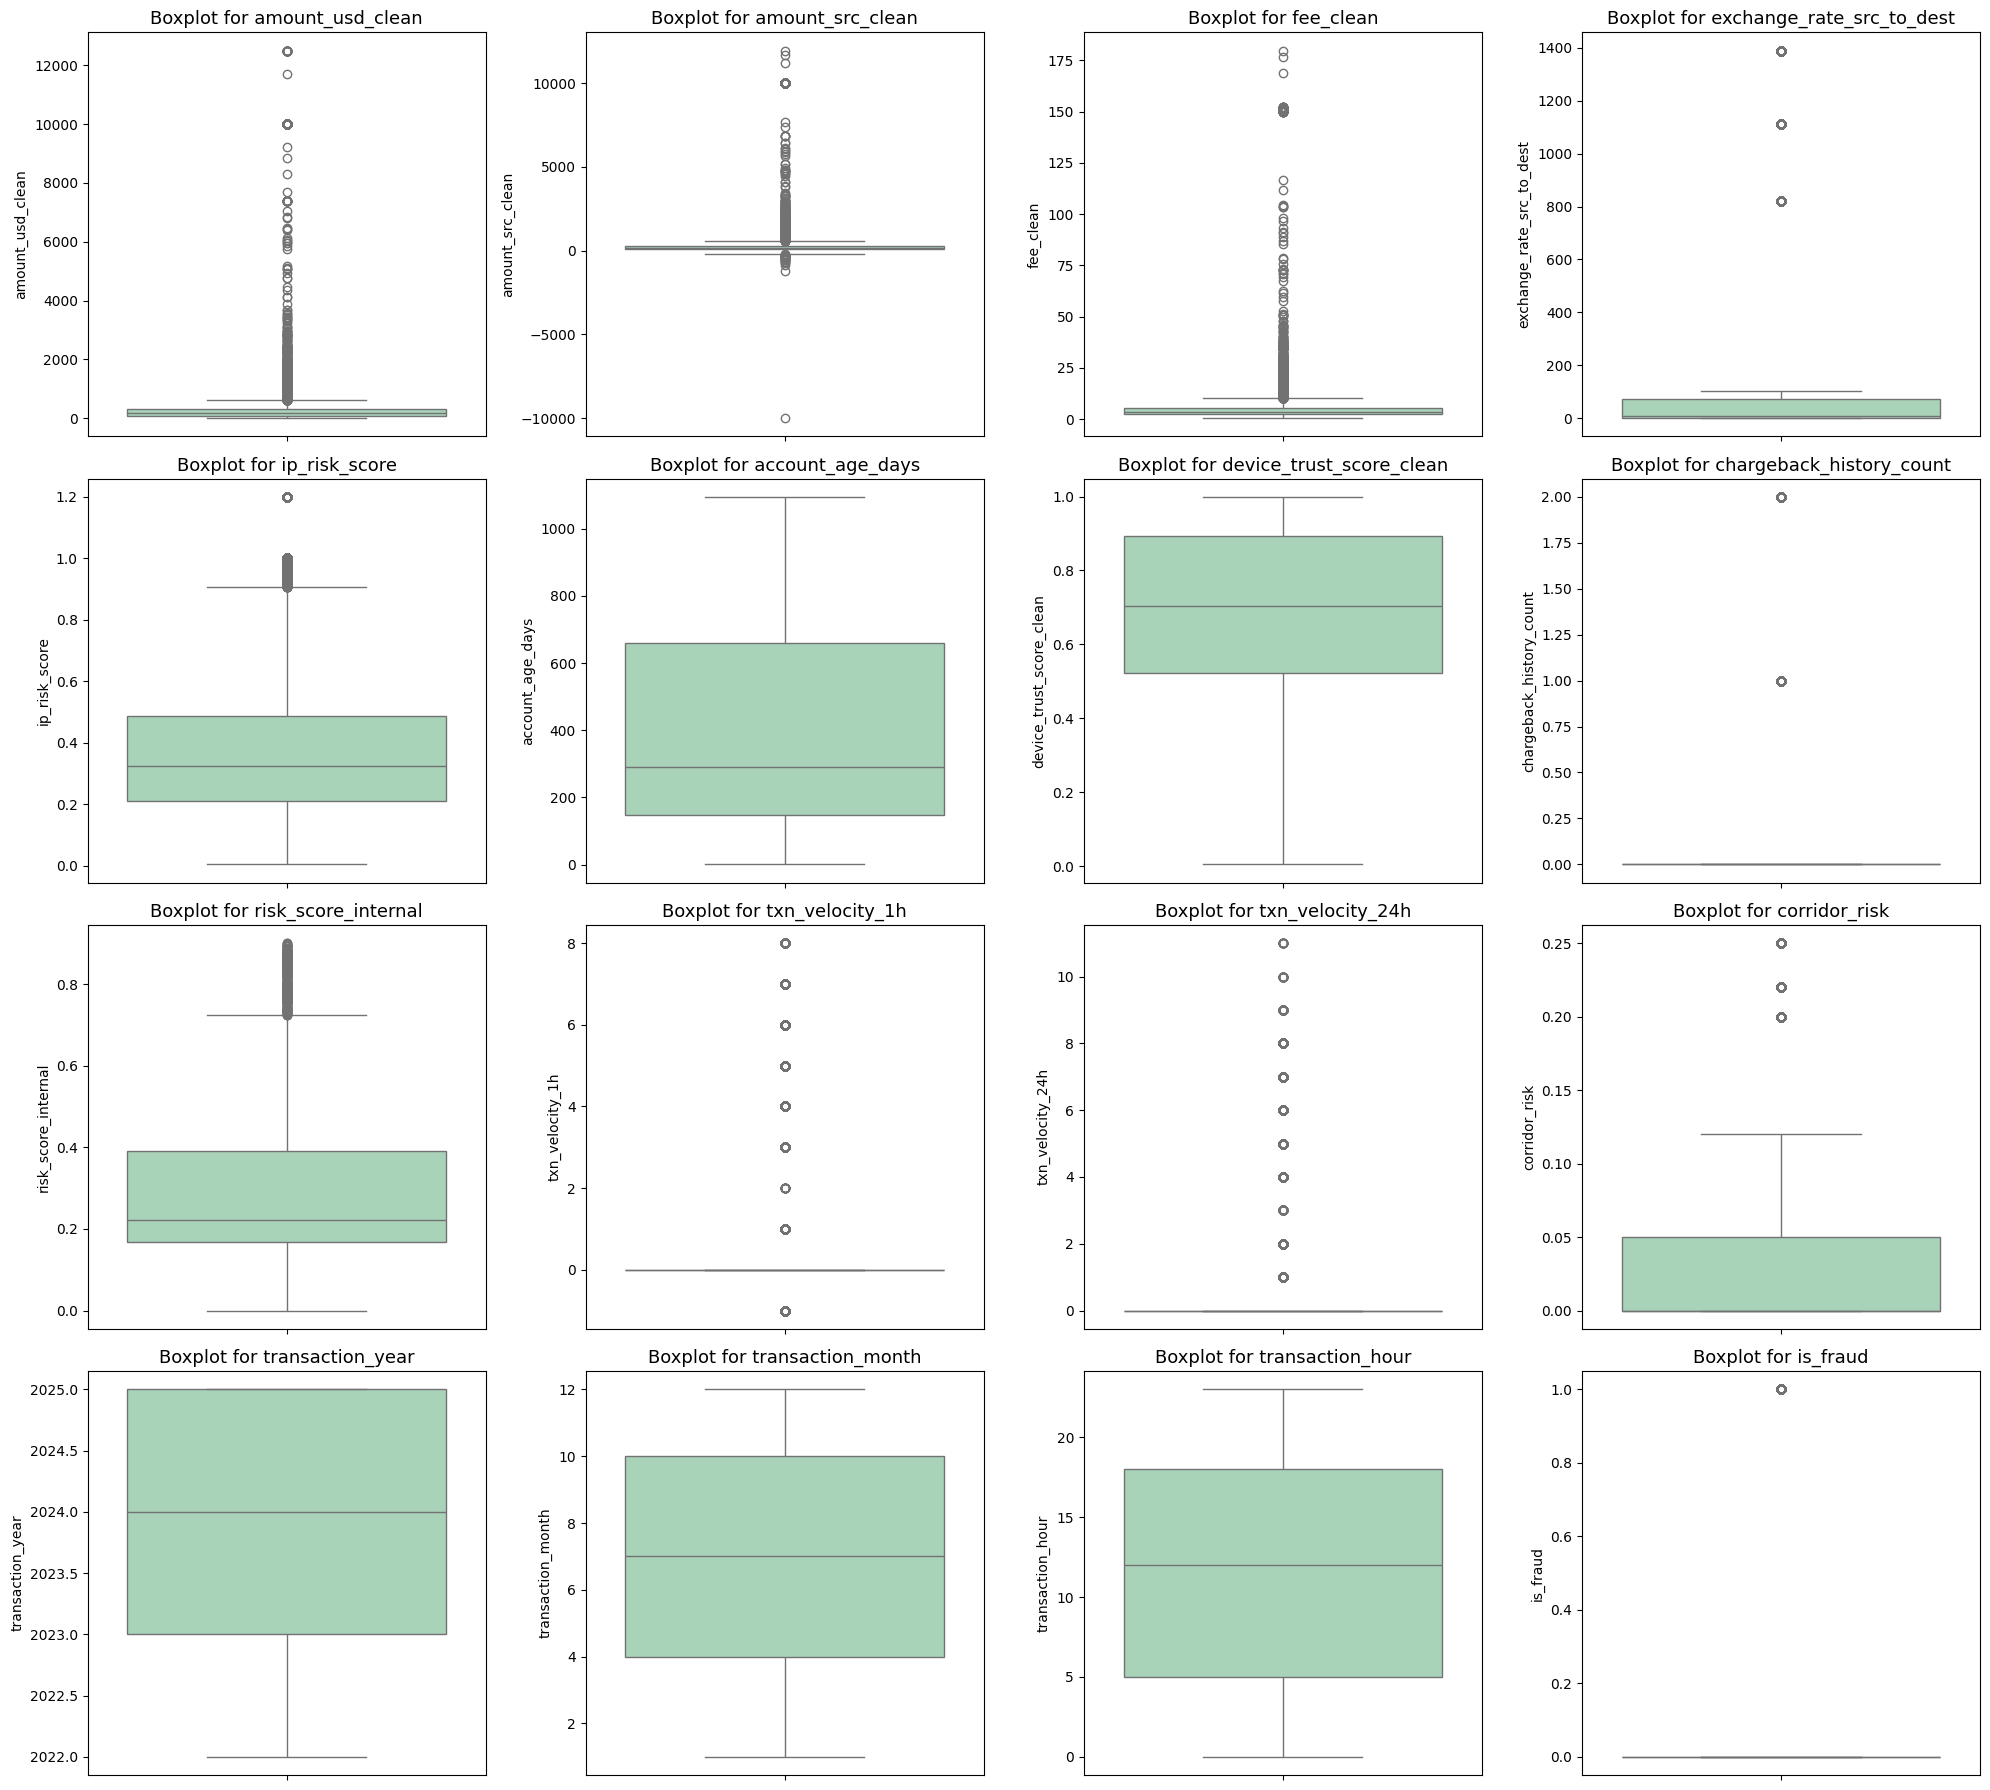

In [550]:
fig, ax = plt.subplots(nrows = 4, ncols = 4, figsize = (20, 18))
ax = ax.flatten()

for idx, col in enumerate (numerical_columns):
    sns.boxplot(data[col], ax =ax[idx], color='#a1dab7')
    ax[idx].set_title(f'Boxplot for {col}', fontsize=13)

plt.tight_layout()
plt.show()

- We can see the presence of outlier across most of the features. But I won't address it using Z-score since am going to scale my features

##### Correlation analysis
let see which features impact most on the target variables

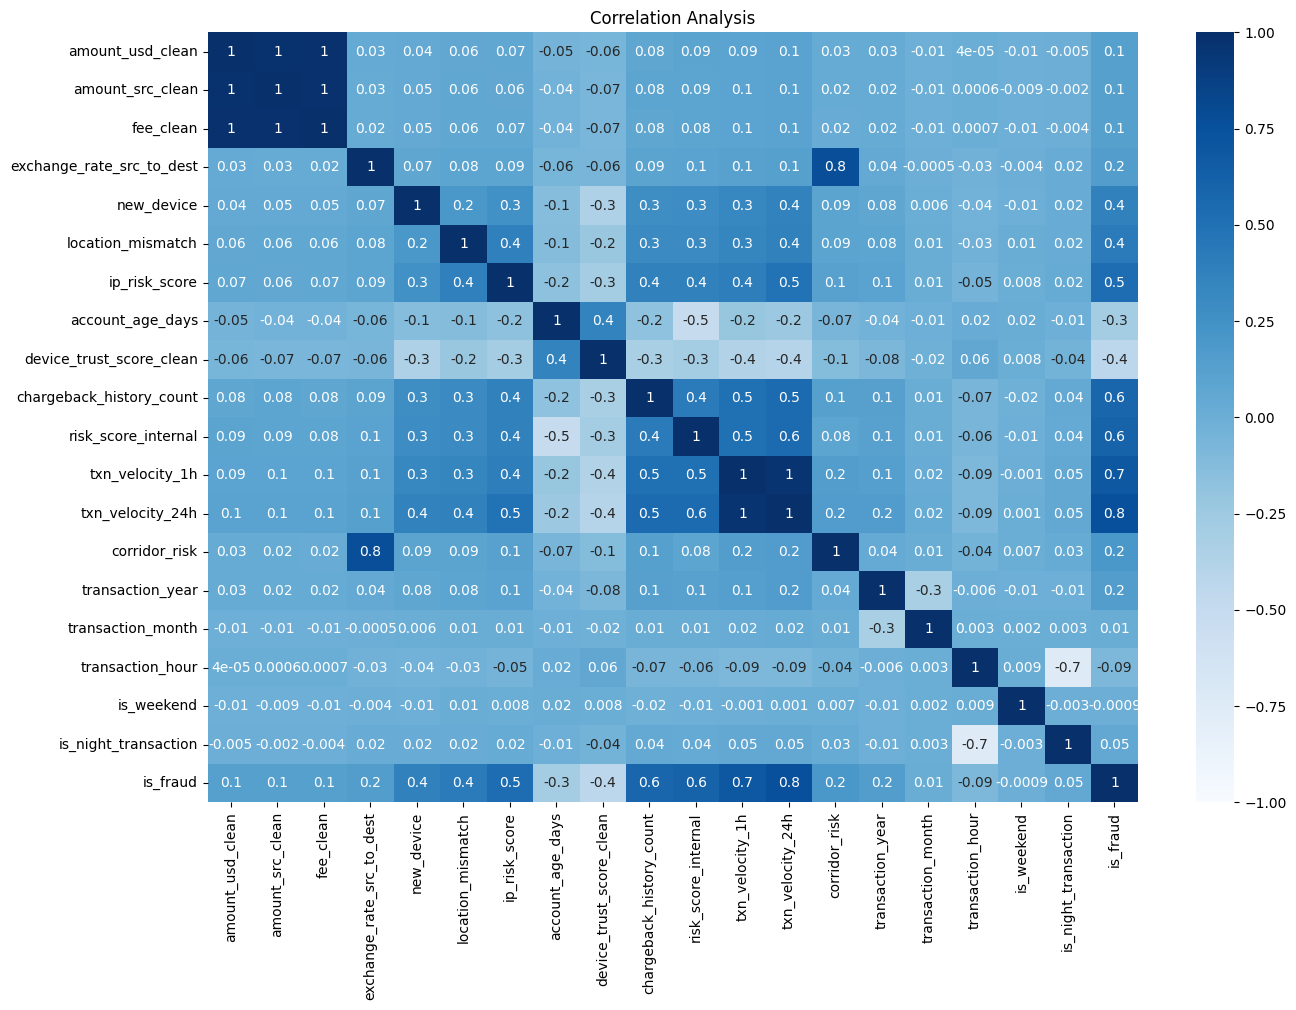

In [556]:
plt.figure(figsize =(15,10))
sns.heatmap(data_cleaned.corr(numeric_only=True), annot =True, fmt=".1g", vmin=-1, vmax=1, cmap ='Blues')
plt.title('Correlation Analysis')
plt.show()

In [ ]:
# Let check for highly duplicated features in terms of multicollinearity. 
# This is highly duplicated features might affect the intrepretation of the feature importance using Tree models
data_cleaned.T.duplicated()

timestamp_clean              False
home_country_clean           False
source_currency              False
dest_currency                False
channel                      False
amount_usd_clean             False
amount_src_clean             False
fee_clean                    False
exchange_rate_src_to_dest    False
new_device                   False
ip_country_clean             False
location_mismatch            False
ip_risk_score                False
kyc_tier_clean               False
account_age_days             False
device_trust_score_clean     False
chargeback_history_count     False
risk_score_internal          False
txn_velocity_1h              False
txn_velocity_24h             False
corridor_risk                False
transaction_year             False
transaction_month            False
transaction_hour             False
transaction_day_of_week      False
is_weekend                   False
is_night_transaction         False
is_fraud                     False
transaction_monthnam

- From the correlation analysis, it very clear that features like chargeback, risk score, transaction velocity in 1h and 24h are show high multicollinearity to the target variables. But since we are training a tree models. I do not think...

- I have confirm the presence of multicollinearity in my model. But since I will be training mostly tree base models like Decision Tree, Random Forest, XGBoost,LightBoost, CatBoost, they are not too sensitive to large numbers,outliers or multicollinearity.

- But since my baseline model is Logistic Regression which sensitive to all these...


In [ ]:
#Let Save the cleaned data
data_cleaned.to_csv("../data/novapay_cleaned.csv", index=False)

In [626]:
#Let be pick the relevant features that I will use for modelling
model_df =data_cleaned[[
    "home_country_clean",
    "source_currency",
    "dest_currency",
    "channel",
    "amount_usd_clean",
    "amount_src_clean",
    "fee_clean",
    "exchange_rate_src_to_dest",
    "new_device",
    "ip_country_clean",
    "location_mismatch",
    "ip_risk_score",
    "kyc_tier_clean",
    "account_age_days",
    "device_trust_score_clean",
    "chargeback_history_count",
    "risk_score_internal",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "corridor_risk",
    "transaction_year",
    "is_fraud"
]]

# I want to rename of the columns name
model_df = model_df.rename(columns ={
    "home_country_clean": "home_country",
    "amount_usd_clean":"amount_usd",
    "amount_src_clean":"amount_src",
    "fee_clean":"fee",
    "ip_country_clean":"ip_country",
    "kyc_tier_clean":"kyc_tier",
    "device_trust_score_clean":"device_trust_score",
    "chargeback_history_count":"chargeback_history(count)",
    "risk_score_internal":"risk_score(internal)"
})

In [638]:
model_df.head(2)

,home_country,source_currency,dest_currency,channel,amount_usd,amount_src,fee,exchange_rate_src_to_dest,new_device,ip_country,...,kyc_tier,account_age_days,device_trust_score,chargeback_history(count),risk_score(internal),txn_velocity_1h,txn_velocity_24h,corridor_risk,transaction_year,is_fraud
0,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,US,...,standard,263,0.522,0,0.223,0,0,0.0,2022,0
1,CA,CAD,MXN,web,154.29,208.51,4.24,12.758621,True,CA,...,standard,947,0.475,0,0.268,0,1,0.0,2022,0


channel_unknown
ip_country_UNKNOWN
kyc_tier_unknown


In [622]:
#Check if there is any duplicate
model_df.duplicated().sum() 

np.int64(0)

#### Encode Categorical Features

In [643]:
#Let's encode the categorical features to numerica
model_df = pd.get_dummies(model_df, dtype=int, drop_first =False)

# # #I want use these channel_unknown, ip_country_UNKNOWN, kyc_tier_unknown featueres as the reference category
model_df.drop(columns =[
    "ip_country_UNKNOWN",
    "kyc_tier_unknown",
        "channel_unknown"],
    errors ='ignore',
    inplace =True)

# Features like new device and location_mismatch are bool columns let turn them to numeric
bool_cols = ['new_device', 'location_mismatch']
model_df[bool_cols ]=model_df[bool_cols].astype(int)

model_df.head(2)

,amount_usd,amount_src,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history(count),...,channel_ATM,channel_mobile,channel_web,ip_country_CA,ip_country_UK,ip_country_UNKNOWN_MISMATCH,ip_country_US,kyc_tier_enhanced,kyc_tier_low,kyc_tier_standard
0,278.19,278.19,4.25,1.351351,0,0,0.123,263,0.522,0,...,1,0,0,0,0,0,1,0,0,1
1,154.29,208.51,4.24,12.758621,1,0,0.569,947,0.475,0,...,0,0,1,1,0,0,0,0,0,1


In [645]:
model_df.info()
print("\n")

print("✅🤗Everything is Good.Data is ready for modellling")

<class 'pandas.core.frame.DataFrame'>
Index: 11140 entries, 0 to 11399
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   amount_usd                   11140 non-null  float64
 1   amount_src                   11140 non-null  float64
 2   fee                          11140 non-null  float64
 3   exchange_rate_src_to_dest    11140 non-null  float64
 4   new_device                   11140 non-null  int64  
 5   location_mismatch            11140 non-null  int64  
 6   ip_risk_score                11140 non-null  float64
 7   account_age_days             11140 non-null  int64  
 8   device_trust_score           11140 non-null  float64
 9   chargeback_history(count)    11140 non-null  int64  
 10  risk_score(internal)         11140 non-null  float64
 11  txn_velocity_1h              11140 non-null  int64  
 12  txn_velocity_24h             11140 non-null  int64  
 13  corridor_risk        

In [640]:
model_df.columns

Index(['amount_usd', 'amount_src', 'fee', 'exchange_rate_src_to_dest',
       'new_device', 'location_mismatch', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'chargeback_history(count)',
       'risk_score(internal)', 'txn_velocity_1h', 'txn_velocity_24h',
       'corridor_risk', 'transaction_year', 'is_fraud', 'home_country_CA',
       'home_country_UK', 'home_country_US', 'source_currency_CAD',
       'source_currency_GBP', 'source_currency_USD', 'dest_currency_CAD',
       'dest_currency_CNY', 'dest_currency_EUR', 'dest_currency_GBP',
       'dest_currency_INR', 'dest_currency_MXN', 'dest_currency_NGN',
       'dest_currency_PHP', 'dest_currency_USD', 'channel_ATM',
       'channel_mobile', 'channel_unknown', 'channel_web', 'ip_country_CA',
       'ip_country_UK', 'ip_country_UNKNOWN', 'ip_country_UNKNOWN_MISMATCH',
       'ip_country_US', 'kyc_tier_enhanced', 'kyc_tier_low',
       'kyc_tier_standard', 'kyc_tier_unknown'],
      dtype='object')

In [619]:
model_df.head(2)

,amount_usd,amount_src,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history(count),...,channel_mobile,channel_unknown,channel_web,ip_country_UK,ip_country_UNKNOWN,ip_country_UNKNOWN_MISMATCH,ip_country_US,kyc_tier_low,kyc_tier_standard,kyc_tier_unknown
0,278.19,278.19,4.25,1.351351,False,False,0.123,263,0.522,0,...,0,0,0,0,0,0,1,0,1,0
1,154.29,208.51,4.24,12.758621,True,False,0.569,947,0.475,0,...,0,0,1,0,0,0,0,0,1,0
